# AI Tối Ưu Lịch Trình MTA — 29 tuyến

Pipeline end-to-end: **dữ liệu** → **mô hình nhu cầu** (MLP + HistGBM blend) → **tối ưu lịch trình** analytical có ràng buộc GTFS.

| Thư mục | Vai trò |
|---------|---------|
| `../datasets/` | Ridership, GTFS, `factors_hourly.csv` |
| `../datasets/schedule_current/` | Lịch baseline (headway, service window) |
| `outputs/default/` | Kết quả chạy: schedules, metrics, figures |
| `outputs/default/ui_export/` | Artifacts cho API/UI (§10) |

**Kịch bản tối ưu:** `weekday_peak`, `weekend`, `rainy_day` (demand quantile p75 cho ngày mưa).

Notebook thử nghiệm 1 tuyến: `mta_schedule_optimization_single_route.ipynb`.

## 1. Setup & imports

Cấu hình đường dẫn, feature thời tiết liên tục, bound chuyến theo nhóm giờ (peak / off-peak / overnight / rainy), và chính sách λ (Pareto knee).

In [1]:
import os
import json
import warnings
import random
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_absolute_error, r2_score

os.environ["TF_CPP_MIN_LOG_LEVEL"] = "2"
import tensorflow as tf
from tensorflow.keras import layers, Model, Input
from tensorflow.keras.callbacks import EarlyStopping

warnings.filterwarnings("ignore")
sns.set_theme(style="whitegrid", context="notebook")
plt.rcParams["figure.dpi"] = 110

SEED = 42
random.seed(SEED)
np.random.seed(SEED)
tf.random.set_seed(SEED)

import sys
import importlib

_cwd = Path(".").resolve()
if (_cwd / "lib" / "single_route_pipeline.py").is_file():
    NOTEBOOK_DIR = _cwd
elif (_cwd / "notebooks" / "lib" / "single_route_pipeline.py").is_file():
    NOTEBOOK_DIR = _cwd / "notebooks"
else:
    raise ImportError(f"Cannot locate notebooks/lib from cwd={_cwd}")

if str(NOTEBOOK_DIR) not in sys.path:
    sys.path.insert(0, str(NOTEBOOK_DIR))

import lib.single_route_pipeline as srp
importlib.reload(srp)

REPO_ROOT = NOTEBOOK_DIR.parent if NOTEBOOK_DIR.name == "notebooks" else NOTEBOOK_DIR
DATA_DIR = REPO_ROOT / "datasets"
SCHEDULE_DIR = REPO_ROOT / "datasets" / "schedule_current"

DEMAND_MODEL_TYPE = "blend"
USE_HISTGBM_BLEND = True
CV_USE_BLEND = True
TUNE_RESID_CLIP_ON_VAL = True
HISTGBM_BLEND_WEIGHT = None

OUT_DIR = Path("outputs/default")
OUT_DIR.mkdir(parents=True, exist_ok=True)

MANIFEST_FILE = DATA_DIR / "train_manifest.json"
if MANIFEST_FILE.exists():
    with open(MANIFEST_FILE, encoding="utf-8") as f:
        train_manifest = json.load(f)
else:
    train_manifest = {}

_DEFAULT_PATHS = {
    "ridership": "ridership.csv",
    "routes_by_station_complex": "routes_by_station_complex.csv",
    "routes": "routes.csv",
    "factors_hourly": "factors_hourly.csv",
    "headway_by_route_hour": "headway_by_route_hour.csv",
    "factors_daily": "factors_daily.csv",
}

def data_path(key: str) -> Path:
    """Resolve path trong DATA_DIR (ridership bundle); không dùng cho GTFS."""
    paths_cfg = train_manifest.get("paths", {}) or {}
    name = paths_cfg.get(key, _DEFAULT_PATHS.get(key, key))
    return DATA_DIR / name

RIDERSHIP_FILE = data_path("ridership")
ROUTES_BY_COMPLEX_FILE = data_path("routes_by_station_complex")
FACTORS_HOURLY_FILE = data_path("factors_hourly")
FACTORS_MODE = "hourly"
FACTORS_JOIN_KEYS = ["date", "hour"]

_scope = train_manifest.get("scope", {})
OPT_HOURS_FALLBACK = _scope.get("hours", list(range(24)))
OPT_HOURS = list(OPT_HOURS_FALLBACK)
USE_GTFS_OPERATING_HOURS = True
MIN_GTFS_TRIPS_PER_HOUR = 1

OPT_ROUTE_MODE = _scope.get("route_mode", "headway")
DIRECTIONS = _scope.get("directions", [0, 1])
MIN_ROUTE_DEMAND_ROWS = 50
ROUTE_ALIASES = train_manifest.get("route_aliases", {"SIR": "SI"})
HEADWAY_SERVICE = "Weekday"

COVERAGE_THR = 0.7
CHUNK_ROWS = 1_000_000
NN_EPOCHS_MAIN = 200
NN_EPOCHS_CV = 80
CV_SPLITS = 8
CV_SEASON_YEARS = 2
HOLDOUT_TEST_SEASON = "autumn"
HOLDOUT_TEST_YEAR = 2025
HOLDOUT_VAL_SEASON = "summer"
HOLDOUT_VAL_YEAR = 2025

USE_ROUTE_EMBEDDING = True
USE_LAG_FEATURES = True
LAG_FEATURE_COLS = ["log_lag_24h", "log_lag_168h", "log_rolling_7d"]
RESID_CLIP = (-0.4, 0.4)
RESID_CLIP_CANDIDATES = [0.35, 0.45, 0.55]
CV_BLEND_TUNE_FRAC = 0.15
PEAK_SAMPLE_WEIGHT = 2.0
NN_HIDDEN = (64, 32)
NN_DROPOUT = 0.25
USE_BATCH_NORM = True
LAMBDA_COST = 150.0
LAMBDA_GRID = [100, 150, 200, 400, 600, 1000]

USE_DEMAND_SPILLOVER = True
SPILLOVER_ALPHA = 0.02  # best hold-out §4a (was 0.05)
SPILLOVER_ALPHA_GRID = [0.0, 0.02, 0.05, 0.08, 0.10]
TRANSFER_MIN_WEIGHT = 0.1

SPILLOVER_ALPHA_ROUTE: dict[str, float] = {
    "GS": 0.0,
    "H":  0.0,
    "Z":  0.0,
    "N":  0.0,
}

RAINY_HOUR_BOOST: dict[int, float] = {
    17: 1.18, 18: 1.22, 19: 1.18, 8: 1.10, 9: 1.10,
}

TRIPS_MIN_FACTOR = 0.5
TRIPS_OVERNIGHT_MIN_FACTOR = 0.32
TRIPS_PEAK_MAX_FACTOR = 1.22
TRIPS_OFFPEAK_MAX_FACTOR = 1.35
TRIPS_OVERNIGHT_MAX_FACTOR = 1.14
TRIPS_MAX_DELTA = 3
# Headway → trips bounds (single source of truth, merged with dynamic baseline bounds in §5)
MIN_HEADWAY_MIN = 3.0    # peak subway ~2–3 min (NYC)
MAX_HEADWAY_MIN = 20.0   # off-peak upper headway
OVERNIGHT_MAX_HEADWAY_MIN = 30.0
TURNAROUND_BUFFER_MIN = 5.0  # terminal dwell each end (MTA ops ~3–5 min; no GTFS field)
MAX_OVERFLOW_PCT = 1.0   # capacity floor target
SMOOTHNESS_MAX_DELTA = TRIPS_MAX_DELTA
LAMBDA_AUTO_CALIBRATE = True
USE_ANALYTICAL_OPT = True   # full 29 routes: analytical
TARGET_MAX_BIND_FRACTION = 0.45
TARGET_PEAK_BIND_FRACTION = 0.35  # λ_calibrate chỉ kiểm peak @ TRIPS_MAX
RAINY_PEAK_TRIPS_MIN_FACTOR = 0.62
RAINY_OFFPEAK_MAX_FACTOR = 1.42
SPLIT_DEMAND_BY_DIRECTION = True

OPT_TARGET = "objective"  # fixed λ_opt (Pareto knee); was "balanced"
LAMBDA_OPT = None  # §5b: Pareto knee trước §6
USE_PARETO_KNEE_LAMBDA = True  # deploy λ = knee, không auto-calibrate đẩy lên
LAMBDA_CANDIDATES: list[float] = []  # filled in §5b

# Quantile GBM cho scenario rủi ro (conservative demand)
RISK_SCENARIOS = ("rainy_day",)
RISK_DEMAND_QUANTILE = 0.75

MC_DROPOUT_SAMPLES = 50
PARETO_N_POINTS = 20

PEAK_HOURS = (7, 8, 9, 17, 18, 19)

HOURLY_FACTOR_COLS = [
    "temperature_c", "apparent_temperature_c",
    "precipitation_mm", "rain_mm", "snowfall_cm",
    "windspeed_kmh", "windgusts_kmh",
    "is_rain", "is_snow", "is_severe_wind",
    "is_major_event_window",
]


print("TensorFlow:", tf.__version__)
print(f"Demand model: {DEMAND_MODEL_TYPE} (MLP + HistGBM)")
print("Data dir:", DATA_DIR.resolve())
print("Output dir:", OUT_DIR.resolve())
for label, p in [
    ("ridership", RIDERSHIP_FILE),
    ("routes_by_station_complex", ROUTES_BY_COMPLEX_FILE),
    ("factors_hourly", FACTORS_HOURLY_FILE),
    ("schedule", SCHEDULE_DIR),
]:
    print(f"  {label}: {'OK' if p.exists() else 'MISSING'} — {p.name if p.is_file() else p}")


TensorFlow: 2.20.0
Demand model: blend (MLP + HistGBM)
Data dir: D:\tranport-public\datasets
Output dir: D:\tranport-public\notebooks\outputs\default
  ridership: OK — ridership.csv
  routes_by_station_complex: OK — routes_by_station_complex.csv
  factors_hourly: OK — factors_hourly.csv
  schedule: OK — D:\tranport-public\datasets\schedule_current


## 2. Load & hợp nhất dữ liệu

Nguồn trong [`datasets/`](../datasets/) (manifest: `train_manifest.json`):

- **Ridership** — nhu cầu theo ga × giờ (đọc chunked).
- **GTFS** — `schedule_current/`; baseline headway **tự dựng** từ `stop_times`.
- **Thời tiết & lịch** — `factors_hourly.csv` join `(date, hour)`.

Ridership được phân bổ lên tuyến theo trọng số chuyến GTFS trong từng giờ.

In [2]:
routes_complex = pd.read_csv(ROUTES_BY_COMPLEX_FILE)
routes_complex["station_complex_id"] = routes_complex["station_complex_id"].astype(str)

route_col = "gtfs_route_ids" if "gtfs_route_ids" in routes_complex.columns else "route_ids_gtfs"
station_to_routes = (
    routes_complex.assign(route=routes_complex[route_col].astype(str).str.split())
    .explode("route")
    .dropna(subset=["route"])
)
station_to_routes = station_to_routes[station_to_routes["route"] != ""]
station_to_routes = station_to_routes[["station_complex_id", "route"]].drop_duplicates()
station_to_routes["route"] = station_to_routes["route"].replace(ROUTE_ALIASES)

print("Tổng map station→route:", len(station_to_routes))
print("Số ga có map:", station_to_routes["station_complex_id"].nunique())
print("Số tuyến xuất hiện:", station_to_routes["route"].nunique())


Tổng map station→route: 767
Số ga có map: 445
Số tuyến xuất hiện: 26


In [3]:
usecols = ["transit_timestamp", "transit_mode", "station_complex_id", "ridership"]
valid_stations = set(station_to_routes["station_complex_id"].unique())

agg_parts = []
for chunk in pd.read_csv(
    RIDERSHIP_FILE,
    usecols=usecols,
    chunksize=CHUNK_ROWS,
    parse_dates=["transit_timestamp"],
    dtype={"station_complex_id": str},
):
    chunk = chunk[chunk["transit_mode"] == "subway"]
    chunk = chunk[chunk["station_complex_id"].isin(valid_stations)]
    if chunk.empty:
        continue
    chunk["date"] = chunk["transit_timestamp"].dt.date
    chunk["hour"] = chunk["transit_timestamp"].dt.hour
    grp = (
        chunk.groupby(["station_complex_id", "date", "hour"], as_index=False)["ridership"]
        .sum()
    )
    agg_parts.append(grp)

ridership_station = pd.concat(agg_parts, ignore_index=True)
print(f"Aggregated (station,date,hour) rows: {len(ridership_station):,}")
print("Date range:", ridership_station["date"].min(), "→", ridership_station["date"].max())


Aggregated (station,date,hour) rows: 7,294,700
Date range: 2023-12-01 → 2025-11-30


In [4]:
ridership_station = (
    ridership_station.groupby(["station_complex_id", "date", "hour"], as_index=False)["ridership"]
    .sum()
)

# Phân bổ ridership ga→tuyến theo trọng số chuyến GTFS (chỉ route hoạt động trong giờ)
headway = srp.build_headway_from_gtfs(SCHEDULE_DIR, service_id=HEADWAY_SERVICE)
headway["route_id"] = headway["route_id"].astype(str)
route_hour_trips = srp.build_route_hour_trip_counts(
    headway, min_trips=MIN_GTFS_TRIPS_PER_HOUR
)
station_route_weights = srp.build_station_route_hour_weights(
    station_to_routes,
    route_hour_trips,
    min_trips=MIN_GTFS_TRIPS_PER_HOUR,
    route_aliases=ROUTE_ALIASES,
)
ridership_route = srp.aggregate_ridership_to_routes(
    ridership_station,
    station_route_weights,
    coverage_thr=COVERAGE_THR,
)

print(f"Total (route,date,hour) records (coverage≥{COVERAGE_THR}): {len(ridership_route):,}")
print(f"Coverage stats: mean={ridership_route['coverage'].mean():.2f}, "
      f"min={ridership_route['coverage'].min():.2f}, "
      f"max={ridership_route['coverage'].max():.2f}")
print(f"Unique dates: {ridership_route['date'].nunique()}")
headway.to_csv(OUT_DIR / "headway_by_route_hour_derived.csv", index=False)

Total (route,date,hour) records (coverage≥0.7): 399,840
Coverage stats: mean=0.99, min=0.70, max=1.00
Unique dates: 731


In [5]:
def load_factors_hourly(path: Path) -> pd.DataFrame:
    """Load hourly weather/calendar; one row per (date, hour)."""
    fh = pd.read_csv(path, parse_dates=["timestamp", "date"])
    if "hour" not in fh.columns:
        fh["hour"] = fh["timestamp"].dt.hour
    keep = [
        "date", "hour", "day_of_week", "is_weekend", "is_us_holiday", "month",
        "temperature_c", "apparent_temperature_c",
        "precipitation_mm", "rain_mm", "snowfall_cm",
        "windspeed_kmh", "windgusts_kmh",
        "is_rain", "is_snow", "is_severe_wind",
        "is_major_event_window",
    ]
    keep = [c for c in keep if c in fh.columns]
    fh = fh[keep].drop_duplicates(subset=["date", "hour"]).copy()
    fh["date"] = pd.to_datetime(fh["date"]).dt.normalize()
    fh["hour"] = fh["hour"].astype(int)
    return fh


factors = load_factors_hourly(FACTORS_HOURLY_FILE)
print("Factors: hourly", factors.shape, "| cols:", len(factors.columns))


Factors: hourly (17544, 17) | cols: 17


In [6]:
ridership_route["date"] = pd.to_datetime(ridership_route["date"]).dt.normalize()
ridership_route["hour"] = ridership_route["hour"].astype(int)


ridership_all = ridership_route.merge(factors, on=FACTORS_JOIN_KEYS, how="left")
if "day_of_week" in ridership_all.columns:
    ridership_all["day_of_week"] = ridership_all["day_of_week"].fillna(
        ridership_all["date"].dt.dayofweek
    )
else:
    ridership_all["day_of_week"] = ridership_all["date"].dt.dayofweek
if "is_weekend" in ridership_all.columns:
    ridership_all["is_weekend"] = ridership_all["is_weekend"].fillna(
        (ridership_all["date"].dt.dayofweek >= 5).astype(int)
    )
else:
    ridership_all["is_weekend"] = (ridership_all["date"].dt.dayofweek >= 5).astype(int)
miss = ridership_all["is_rain"].isna().mean() if "is_rain" in ridership_all.columns else 1.0
print(f"Merge hourly on {FACTORS_JOIN_KEYS}: missing weather rows = {miss:.2%}")

flag_cols = [
    "is_us_holiday", "is_rain", "is_snow", "is_severe_wind",
    "is_major_event_window",
]
num_cols = [c for c in HOURLY_FACTOR_COLS if c not in flag_cols]

for c in num_cols:
    if c not in ridership_all.columns:
        ridership_all[c] = 0.0
    ridership_all[c] = ridership_all[c].fillna(ridership_all[c].median())
for c in flag_cols:
    if c not in ridership_all.columns:
        ridership_all[c] = 0
    ridership_all[c] = ridership_all[c].fillna(0).astype(int)

print("Merged ridership shape:", ridership_all.shape)
print("Hours:", sorted(ridership_all["hour"].unique()))


Merge hourly on ['date', 'hour']: missing weather rows = 0.00%
Merged ridership shape: (399840, 20)
Hours: [np.int64(0), np.int64(1), np.int64(2), np.int64(3), np.int64(4), np.int64(5), np.int64(6), np.int64(7), np.int64(8), np.int64(9), np.int64(10), np.int64(11), np.int64(12), np.int64(13), np.int64(14), np.int64(15), np.int64(16), np.int64(17), np.int64(18), np.int64(19), np.int64(20), np.int64(21), np.int64(22), np.int64(23)]


## 3. EDA & chọn scope tuyến

Chọn `OPT_ROUTES` (29 tuyến có ridership) và lọc slot `(route × direction × hour)` theo cửa sổ phục vụ GTFS.

In [7]:
HEADWAY_ROUTES = sorted(headway["route_id"].astype(str).unique())
route_row_counts = ridership_all.groupby("route_id").size()
RIDERSHIP_ROUTES = route_row_counts[route_row_counts >= MIN_ROUTE_DEMAND_ROWS].index.astype(str).tolist()

if OPT_ROUTE_MODE == "headway":
    OPT_ROUTES = HEADWAY_ROUTES
elif OPT_ROUTE_MODE == "intersection":
    OPT_ROUTES = sorted(set(HEADWAY_ROUTES) & set(RIDERSHIP_ROUTES))
else:
    OPT_ROUTES = RIDERSHIP_ROUTES

EXCLUDED_NO_RIDERSHIP = [r for r in OPT_ROUTES if r not in set(RIDERSHIP_ROUTES)]
OPT_ROUTES = [r for r in OPT_ROUTES if r in set(RIDERSHIP_ROUTES)]
if EXCLUDED_NO_RIDERSHIP:
    print(f"Loại {len(EXCLUDED_NO_RIDERSHIP)} tuyến không có ridership: {EXCLUDED_NO_RIDERSHIP}")

route_totals = (
    ridership_all.groupby("route_id")["demand"].mean().sort_values(ascending=False)
)
print("Top 12 tuyến theo demand TB/giờ:")
print(route_totals.head(12).round(0))
print()
print(f"OPT_ROUTES ({len(OPT_ROUTES)} tuyến, mode={OPT_ROUTE_MODE}):", OPT_ROUTES[:8], "...")

route_hours = {r: list(OPT_HOURS_FALLBACK) for r in OPT_ROUTES}
route_dir_hours: dict[tuple[str, int], list[int]] = {}
if USE_GTFS_OPERATING_HOURS:
    route_dir_hours = srp.derive_operating_hours_by_route_direction(
        headway, OPT_ROUTES, directions=DIRECTIONS, min_trips=MIN_GTFS_TRIPS_PER_HOUR
    )
    route_hours = srp.derive_operating_hours_by_route(
        headway, OPT_ROUTES, directions=DIRECTIONS, min_trips=MIN_GTFS_TRIPS_PER_HOUR
    )
    empty = [k for k, hs in route_dir_hours.items() if not hs]
    if empty:
        raise ValueError(f"Không có giờ GTFS cho: {empty[:8]}")
    OPT_HOURS = sorted({h for hs in route_dir_hours.values() for h in hs})
    print(f"GTFS operating hours (route×dir): {len(route_dir_hours)} keys, union {len(OPT_HOURS)} hours")
    lens = [len(hs) for hs in route_dir_hours.values()]
    print(f"  hours per route×dir: min={min(lens)}, max={max(lens)}")

OPT_SCOPE = [
    (r, d, h) for r in OPT_ROUTES for d in DIRECTIONS
    for h in (route_dir_hours.get((r, d)) or route_hours.get(r, OPT_HOURS_FALLBACK))
]
print(f"OPT_SCOPE slots (pre-filter ridership): {len(OPT_SCOPE)}")

df = ridership_all[ridership_all["route_id"].isin(OPT_ROUTES)].copy()
n_all = len(df)
if USE_GTFS_OPERATING_HOURS:
    df = df[df.apply(lambda row: row["hour"] in route_hours.get(row["route_id"], []), axis=1)].copy()
print()
print(f"Dataset NN: {len(df):,} bản ghi ({n_all:,} trước lọc giờ), "
      f"{df['date'].nunique()} ngày, routes={df['route_id'].nunique()}")
print(f"Demand range: {df['demand'].min():.0f} – {df['demand'].max():.0f}")



Loại 4 tuyến không có ridership: ['6X', '7X', 'FX', 'SI']
Top 12 tuyến theo demand TB/giờ:
route_id
1    12432.0
6    11288.0
7    10615.0
F     9366.0
R     8622.0
C     7875.0
A     7577.0
E     6989.0
B     6949.0
Q     6782.0
L     6694.0
M     6288.0
Name: demand, dtype: float64

OPT_ROUTES (25 tuyến, mode=headway): ['1', '2', '3', '4', '5', '6', '7', 'A'] ...
GTFS operating hours (route×dir): 50 keys, union 24 hours
  hours per route×dir: min=2, max=24
OPT_SCOPE slots (pre-filter ridership): 1104

Dataset NN: 399,840 bản ghi (399,840 trước lọc giờ), 731 ngày, routes=25
Demand range: 1 – 47212


## 3b. Transfer network & demand spillover

- Ma trận chuyển tuyến từ ga chung (`build_transfer_matrix`).
- `adjust_demand_with_spillover` trước bước optimize.
- Hệ số α chọn trên hold-out ở §4a.

In [8]:
# BƯỚC 1 — Transfer adjacency (route × route)
transfer_matrix = srp.build_transfer_matrix(
    routes_complex,
    OPT_ROUTES,
    route_aliases=ROUTE_ALIASES,
    min_weight=TRANSFER_MIN_WEIGHT,
)
_off_diag = ((transfer_matrix > 0).values) & (~np.eye(len(transfer_matrix), dtype=bool))
_n_off = int(_off_diag.sum())
print(f"Transfer matrix: {transfer_matrix.shape[0]} routes | "
      f"nonzero pairs={int((transfer_matrix > 0).sum().sum())} | "
      f"off-diag connections={_n_off}")
print("Top connectivity (sum weight):")
print(transfer_matrix.sum(axis=1).sort_values(ascending=False).head(8).round(2).to_string())
transfer_matrix.to_csv(OUT_DIR / "transfer_matrix.csv")
print("Đã lưu:", OUT_DIR / "transfer_matrix.csv")

Transfer matrix: 25 routes | nonzero pairs=143 | off-diag connections=118
Top connectivity (sum weight):
R     2.94
GS    2.88
2     2.60
N     2.54
W     2.53
5     2.46
B     2.45
E     2.37
Đã lưu: outputs\default\transfer_matrix.csv


In [9]:
MISSING_RIDERSHIP_ROUTES = list(EXCLUDED_NO_RIDERSHIP)
print(f"Tuyến đã loại khỏi pipeline (không ridership): {MISSING_RIDERSHIP_ROUTES or []}")


Tuyến đã loại khỏi pipeline (không ridership): ['6X', '7X', 'FX', 'SI']


## 4. Huấn luyện demand model

Hold-out theo mùa (`autumn_2025` test). Target: phần dư log-demand so với baseline GTFS.

- **MLP** (Keras) + **HistGBM** blend, clip residual.
- Feature: chu kỳ thời gian, lễ, thời tiết liên tục, lag demand.
- Output: `demand_model.keras`, `histgbm_blend.pkl`, `scaler.pkl`.

In [10]:
df = df.sort_values(["route_id", "date", "hour"]).reset_index(drop=True)

if "month" not in df.columns:
    df["month"] = df["date"].dt.month

df = srp.add_cyclical_time_features(df)

route_to_idx = {r: i for i, r in enumerate(sorted(OPT_ROUTES))}
df["route_idx"] = df["route_id"].map(route_to_idx).astype(int)

df = srp.add_lag_features(df, use_lags=USE_LAG_FEATURES, lag_cols=LAG_FEATURE_COLS)

unique_dates = sorted(df["date"].unique())
n_dates = len(unique_dates)

train_dates, val_dates, test_dates, holdout_meta = srp.build_seasonal_holdout_splits(
    unique_dates,
    test_season=HOLDOUT_TEST_SEASON,
    test_season_year=HOLDOUT_TEST_YEAR,
    val_season=HOLDOUT_VAL_SEASON,
    val_season_year=HOLDOUT_VAL_YEAR,
    auto_adjust=False,
    return_meta=True,
)
HOLDOUT_TEST_SEASON = holdout_meta["test_season"]
HOLDOUT_TEST_YEAR = holdout_meta["test_season_year"]
HOLDOUT_VAL_SEASON = holdout_meta["val_season"]
HOLDOUT_VAL_YEAR = holdout_meta["val_season_year"]

train_df = df[df["date"].isin(train_dates)].copy()
val_df   = df[df["date"].isin(val_dates)].copy()
test_df  = df[df["date"].isin(test_dates)].copy()

baseline_lookup = (
    train_df.groupby(["route_id", "hour", "is_weekend"])["demand"]
    .median()
    .rename("baseline_demand")
)
fallback = train_df.groupby(["route_id", "hour"])["demand"].median().rename("fallback_demand")


def attach_baseline(d: pd.DataFrame) -> pd.DataFrame:
    d = d.merge(baseline_lookup, on=["route_id", "hour", "is_weekend"], how="left")
    d = d.merge(fallback, on=["route_id", "hour"], how="left")
    d["baseline_demand"] = d["baseline_demand"].fillna(d["fallback_demand"])
    return d.drop(columns=["fallback_demand"])


train_df = attach_baseline(train_df)
val_df   = attach_baseline(val_df)
test_df  = attach_baseline(test_df)

train_df = srp.fill_lag_from_train(train_df, train_df, lag_cols=LAG_FEATURE_COLS)
val_df   = srp.fill_lag_from_train(val_df, train_df, lag_cols=LAG_FEATURE_COLS)
test_df  = srp.fill_lag_from_train(test_df, train_df, lag_cols=LAG_FEATURE_COLS)

for part in (train_df, val_df, test_df):
    part["log_baseline"] = np.log1p(part["baseline_demand"])

NUM_FEATURES = srp.build_num_feature_list(
    HOURLY_FACTOR_COLS,
    use_lags=USE_LAG_FEATURES,
    lag_cols=LAG_FEATURE_COLS,
)
NUM_FEATURES = [c for c in NUM_FEATURES if c in train_df.columns]
print(f"NUM_FEATURES ({len(NUM_FEATURES)}):", NUM_FEATURES)

lag_feature_defaults = {}
if USE_LAG_FEATURES:
    lag_med = train_df.groupby(["route_id", "hour"])[LAG_FEATURE_COLS].median()
    for (rid, hour), row in lag_med.iterrows():
        lag_feature_defaults[f"{rid}|{hour}"] = {c: float(row[c]) for c in LAG_FEATURE_COLS}

print(f"Hold-out theo mùa: test={HOLDOUT_TEST_SEASON}_{HOLDOUT_TEST_YEAR}, "
      f"val={HOLDOUT_VAL_SEASON}_{HOLDOUT_VAL_YEAR}")
print(f"{n_dates} ngày → train {len(train_dates)} / val {len(val_dates)} / test {len(test_dates)}")
print(f"Train: {len(train_df):,} | Val: {len(val_df):,} | Test: {len(test_df):,}")

y_train = np.log1p(train_df["demand"].values) - train_df["log_baseline"].values
y_val   = np.log1p(val_df["demand"].values) - val_df["log_baseline"].values
y_test  = np.log1p(test_df["demand"].values) - test_df["log_baseline"].values

scaler = StandardScaler()
X_train_num = scaler.fit_transform(train_df[NUM_FEATURES])
X_val_num   = scaler.transform(val_df[NUM_FEATURES])
X_test_num  = scaler.transform(test_df[NUM_FEATURES])
X_train_route = train_df["route_idx"].values.reshape(-1, 1)
X_val_route   = val_df["route_idx"].values.reshape(-1, 1)
X_test_route  = test_df["route_idx"].values.reshape(-1, 1)

print("Target (residual log demand) — train mean: {:.3f}, std: {:.3f}".format(
    y_train.mean(), y_train.std()))


NUM_FEATURES (23): ['hour_sin', 'hour_cos', 'dow_sin', 'dow_cos', 'month_sin', 'month_cos', 'is_weekend', 'is_us_holiday', 'temperature_c', 'apparent_temperature_c', 'precipitation_mm', 'rain_mm', 'snowfall_cm', 'windspeed_kmh', 'windgusts_kmh', 'is_rain', 'is_snow', 'is_severe_wind', 'is_major_event_window', 'log_baseline', 'log_lag_24h', 'log_lag_168h', 'log_rolling_7d']
Hold-out theo mùa: test=autumn_2025, val=summer_2025
731 ngày → train 548 / val 92 / test 91
Train: 299,072 | Val: 50,805 | Test: 49,963
Target (residual log demand) — train mean: -0.019, std: 0.232


In [11]:
histgbm_model = None
blend_weight_mlp = 0.5
blend_weight_tuned = False


def make_demand_model(n_routes: int, n_num_features: int) -> Model:
    return srp.build_demand_model(
        n_routes,
        n_num_features,
        use_route_embedding=USE_ROUTE_EMBEDDING,
        hidden=NN_HIDDEN,
        dropout=NN_DROPOUT,
        use_batch_norm=USE_BATCH_NORM,
    )


def _fit_inputs(route_idx, num_feat):
    return srp.format_keras_inputs(
        route_idx, num_feat, use_route_embedding=USE_ROUTE_EMBEDDING
    )


model = make_demand_model(len(route_to_idx), len(NUM_FEATURES))
model.summary()


Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ route_idx           │ (None, 1)         │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ route_emb           │ (None, 1, 4)      │        100 │ route_idx[0][0]   │
│ (Embedding)         │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ flatten (Flatten)   │ (None, 4)         │          0 │ route_emb[0][0]   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ num_features        │ (None, 23)        │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ concatenate         │ (None, 27)        │          0 │ flatten[0][0],    │
│ (Concatenate)       │                   │            │ num_features[0][… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_0 (Dense)     │ (None, 64)        │      1,792 │ concatenate[0][0] │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ bn_0                │ (None, 64)        │        256 │ dense_0[0][0]     │
│ (BatchNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_0 (Dropout) │ (None, 64)        │          0 │ bn_0[0][0]        │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_1 (Dense)     │ (None, 32)        │      2,080 │ dropout_0[0][0]   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ bn_1                │ (None, 32)        │        128 │ dense_1[0][0]     │
│ (BatchNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_1 (Dropout) │ (None, 32)        │          0 │ bn_1[0][0]        │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ residual_log_demand │ (None, 1)         │         33 │ dropout_1[0][0]   │
│ (Dense)             │                   │            │                   │
└─────────────────────┴───────────────────┴────────────┴───────────────────┘

 Total params: 4,389 (17.14 KB)

 Trainable params: 4,197 (16.39 KB)

 Non-trainable params: 192 (768.00 B)

In [12]:
train_weights = np.ones(len(train_df), dtype=float)
if PEAK_SAMPLE_WEIGHT > 1.0:
    peak_mask = train_df["hour"].isin(PEAK_HOURS)
    train_weights[peak_mask.to_numpy()] = PEAK_SAMPLE_WEIGHT
    print(f"Peak sample weight ×{PEAK_SAMPLE_WEIGHT}: {peak_mask.sum():,}/{len(train_df):,} rows")

early = EarlyStopping(monitor="val_loss", patience=25, restore_best_weights=True)
lr_reduce = tf.keras.callbacks.ReduceLROnPlateau(monitor="val_loss", factor=0.5, patience=8, min_lr=1e-5)

history = model.fit(
    _fit_inputs(X_train_route, X_train_num),
    y_train,
    validation_data=(_fit_inputs(X_val_route, X_val_num), y_val),
    sample_weight=train_weights,
    epochs=NN_EPOCHS_MAIN,
    batch_size=32,
    verbose=0,
    callbacks=[early, lr_reduce],
)
print(f"Stop @ epoch {len(history.history['loss'])} | best val_mae={min(history.history.get('val_mae', history.history['loss'])):.4f}")

if USE_HISTGBM_BLEND:
    histgbm_model = srp.fit_histgbm_demand(X_train_num, y_train, sample_weight=train_weights)
    print("HistGBM (literature tree baseline) fitted.")


Peak sample weight ×2.0: 79,636/299,072 rows
Stop @ epoch 73 | best val_mae=0.0884
HistGBM (literature tree baseline) fitted.


  val MAE @ clip ±0.35: 453.1
  val MAE @ clip ±0.45: 451.0
  val MAE @ clip ±0.55: 449.5
→ Chọn RESID_CLIP = ±0.55 (val MAE=449.5)
Blend val: MLP weight=0.80 (MAE=448.7)
=== Hold-out test ===
  blend | test=autumn_2025
  Baseline: MAE=961 RMSE=1,696 R²=+0.932 MAPE=16.2% SMAPE=16.6%
  Model:    MAE=489 RMSE=961 R²=+0.978 MAPE=8.9% SMAPE=9.3%  (ΔMAE +49.1%)


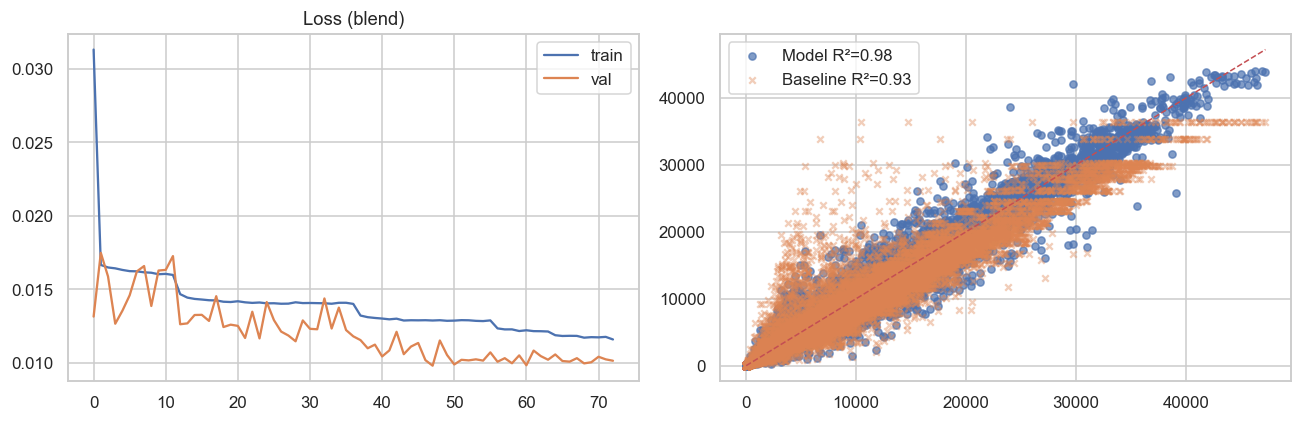

In [13]:
if TUNE_RESID_CLIP_ON_VAL:
    best_clip, best_mae = RESID_CLIP[1], float("inf")
    for clip_hi in RESID_CLIP_CANDIDATES:
        tmp_clip = (-clip_hi, clip_hi)
        pred_resid = model.predict(_fit_inputs(X_val_route, X_val_num), verbose=0).ravel()
        pred_resid = np.clip(pred_resid, *tmp_clip)
        pred_val = np.expm1(val_df["log_baseline"].values + pred_resid)
        mae_val = mean_absolute_error(val_df["demand"].values, pred_val)
        print(f"  val MAE @ clip ±{clip_hi:.2f}: {mae_val:,.1f}")
        if mae_val < best_mae:
            best_mae, best_clip = mae_val, clip_hi
    RESID_CLIP = (-best_clip, best_clip)
    print(f"→ Chọn RESID_CLIP = ±{best_clip:.2f} (val MAE={best_mae:,.1f})")


def _predict_resid_mlp(route_idx_arr, num_feat_arr):
    return model.predict(_fit_inputs(route_idx_arr, num_feat_arr), verbose=0).ravel()


blend_weight_tuned = False


def tune_blend_weight_mlp() -> None:
    """Chọn trọng số MLP/HistGBM trên val — chỉ chạy một lần."""
    global blend_weight_mlp, blend_weight_tuned
    if histgbm_model is None:
        return
    if blend_weight_tuned:
        return
    if HISTGBM_BLEND_WEIGHT is not None:
        blend_weight_mlp = float(HISTGBM_BLEND_WEIGHT)
        blend_weight_tuned = True
        return
    pred_mlp = np.clip(_predict_resid_mlp(X_val_route, X_val_num), *RESID_CLIP)
    pred_gbm = histgbm_model.predict(X_val_num)
    best_w, best_mae = 0.5, float("inf")
    for w in np.linspace(0.2, 0.8, 7):
        pr = srp.blend_residual_predictions(pred_mlp, pred_gbm, w)
        pv = srp.residuals_to_demand(val_df["log_baseline"].values, pr, RESID_CLIP)
        m = mean_absolute_error(val_df["demand"].values, pv)
        if m < best_mae:
            best_mae, best_w = m, w
    blend_weight_mlp = best_w
    blend_weight_tuned = True
    print(f"Blend val: MLP weight={blend_weight_mlp:.2f} (MAE={best_mae:,.1f})")


def predict_demand(route_idx_arr, num_feat_arr, log_baseline):
    pred_mlp = np.clip(_predict_resid_mlp(route_idx_arr, num_feat_arr), *RESID_CLIP)
    if histgbm_model is not None:
        pred_gbm = histgbm_model.predict(num_feat_arr)
        tune_blend_weight_mlp()
        pred_resid = srp.blend_residual_predictions(pred_mlp, pred_gbm, blend_weight_mlp)
    else:
        pred_resid = pred_mlp
    return srp.residuals_to_demand(log_baseline, pred_resid, RESID_CLIP)


y_pred = predict_demand(X_test_route, X_test_num, test_df["log_baseline"].values)

y_true = test_df["demand"].values
baseline_pred_test = test_df["baseline_demand"].values
m_base = srp.regression_metrics(y_true, baseline_pred_test)
m_nn = srp.regression_metrics(y_true, y_pred)
mae_impr = (m_base["mae"] - m_nn["mae"]) / m_base["mae"] * 100

nn_eval_metrics = {
    "holdout": {
        "test_block": f"{HOLDOUT_TEST_SEASON}_{HOLDOUT_TEST_YEAR}",
        "val_block": f"{HOLDOUT_VAL_SEASON}_{HOLDOUT_VAL_YEAR}",
        "n_test": int(len(test_df)),
        "model_type": "blend",
        "blend_mlp_weight": float(blend_weight_mlp) if histgbm_model is not None else None,
        "baseline": m_base,
        "model": m_nn,
        "mae_improvement_pct": float(mae_impr),
        "resid_clip": float(RESID_CLIP[1]),
    },
}

def _fmt(m):
    return f"MAE={m['mae']:,.0f} RMSE={m['rmse']:,.0f} R²={m['r2']:+.3f} MAPE={m['mape_pct']:.1f}% SMAPE={m['smape_pct']:.1f}%"

print("=== Hold-out test ===")
print(f"  {DEMAND_MODEL_TYPE} | test={HOLDOUT_TEST_SEASON}_{HOLDOUT_TEST_YEAR}")
print(f"  Baseline: {_fmt(m_base)}")
print(f"  Model:    {_fmt(m_nn)}  (ΔMAE {mae_impr:+.1f}%)")

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
axes[0].plot(history.history["loss"], label="train")
if "val_loss" in history.history:
    axes[0].plot(history.history["val_loss"], label="val")
axes[0].set_title(f"Loss ({DEMAND_MODEL_TYPE})")
axes[0].legend()
axes[1].scatter(y_true, y_pred, alpha=0.7, s=22, label=f"Model R²={m_nn['r2']:.2f}")
axes[1].scatter(y_true, baseline_pred_test, alpha=0.4, s=18, marker="x", label=f"Baseline R²={m_base['r2']:.2f}")
lim = max(y_true.max(), y_pred.max())
axes[1].plot([0, lim], [0, lim], "r--", lw=1)
axes[1].legend()
plt.tight_layout()
plt.savefig(OUT_DIR / "fig_nn_eval.png", dpi=120, bbox_inches="tight")
plt.show()



## 4a. Kiểm định spillover (hold-out)

Quét `SPILLOVER_ALPHA_GRID` trên test set; chọn α tối thiểu MAE. Output: `spillover_alpha_scan.csv`, `fig_transfer_spillover.png`.

=== Spillover MAE (hold-out route×hour mean) ===
 mae_before  mae_after  mae_delta  alpha
     108.05     108.05       0.00   0.00
     108.05     170.95     -62.90   0.02
     108.05     345.39    -237.34   0.05
     108.05     534.11    -426.06   0.08
     108.05     661.59    -553.54   0.10
Best alpha=0.00 | MAE 108.1 → 108.1 (Δ=+0.0)

Top tuyến benefit nhất @ alpha=0.02:
route_id  mae_before  mae_after  benefit  n_hours
       M      226.65      95.94   130.71       24
       J      199.86     172.08    27.78       24
       G      116.35      92.58    23.77       24
       1      176.31     157.47    18.84       24
      FS       15.76      15.76     0.00       24
       L      379.12     379.12     0.00       24
       6      157.70     165.67    -7.97       24
       7      121.43     142.14   -20.71       24
       Q       70.30     100.08   -29.78       24
       H        1.69      51.92   -50.23       24
Bottom (spillover làm tệ hơn):
route_id  mae_before  mae_after  benefit 

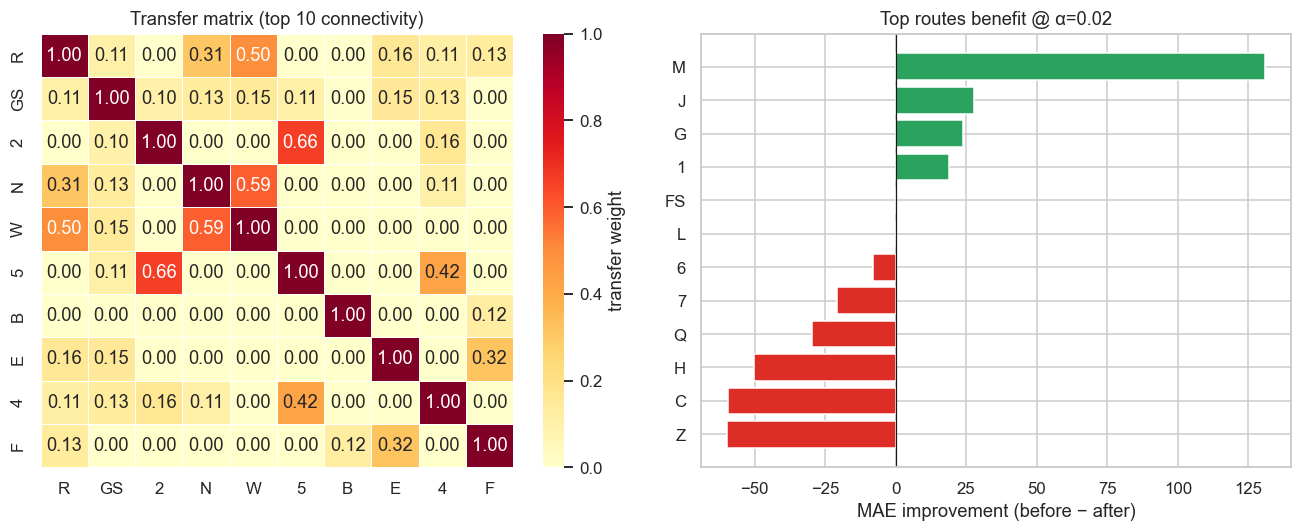

Đã lưu: outputs\default\spillover_alpha_scan.csv | outputs\default\fig_transfer_spillover.png


In [14]:
# BƯỚC 3 — Validate spillover trên hold-out test
_hours_sorted = sorted(test_df["hour"].unique())
_test_agg = (
    test_df.assign(y_pred=y_pred)
    .groupby(["route_id", "hour"], as_index=False)
    .agg(demand_actual=("demand", "mean"), demand_pred=("y_pred", "mean"))
)
_routes_val = [r for r in OPT_ROUTES if r in _test_agg["route_id"].values]
_actual_dict = srp.route_hour_df_to_demand_dict(
    _test_agg.rename(columns={"demand_actual": "demand"}),
    _routes_val, _hours_sorted, demand_col="demand",
)
_pred_dict = srp.route_hour_df_to_demand_dict(
    _test_agg.rename(columns={"demand_pred": "demand"}),
    _routes_val, _hours_sorted, demand_col="demand",
)

_alpha_rows = []
for a in SPILLOVER_ALPHA_GRID:
    m = srp.evaluate_spillover_forecast_mae(
        _actual_dict, _pred_dict, transfer_matrix, alpha=a
    )
    _alpha_rows.append(m)
spillover_alpha_scan = pd.DataFrame(_alpha_rows)
_best = spillover_alpha_scan.loc[spillover_alpha_scan["mae_after"].idxmin()]
print("=== Spillover MAE (hold-out route×hour mean) ===")
print(spillover_alpha_scan.round(2).to_string(index=False))
print(f"Best alpha={_best['alpha']:.2f} | MAE {_best['mae_before']:.1f} → {_best['mae_after']:.1f} "
      f"(Δ={_best['mae_delta']:+.1f})")

spillover_benefit = srp.spillover_benefit_by_route(
    _actual_dict, _pred_dict, transfer_matrix, alpha=float(SPILLOVER_ALPHA)
)
print(f"\nTop tuyến benefit nhất @ alpha={SPILLOVER_ALPHA}:")
print(spillover_benefit.head(10).round(2).to_string(index=False))
print("Bottom (spillover làm tệ hơn):")
print(spillover_benefit.tail(5).round(2).to_string(index=False))

fig, axes = plt.subplots(1, 2, figsize=(12, 5))
srp.plot_transfer_heatmap(
    transfer_matrix, top_n=10, ax=axes[0],
    title="Transfer matrix (top 10 connectivity)",
)
axes[1].barh(
    spillover_benefit.head(12)["route_id"],
    spillover_benefit.head(12)["benefit"],
    color=np.where(spillover_benefit.head(12)["benefit"] >= 0, "#2ca25f", "#de2d26"),
)
axes[1].axvline(0, color="k", lw=0.8)
axes[1].set_xlabel("MAE improvement (before − after)")
axes[1].set_title(f"Top routes benefit @ α={SPILLOVER_ALPHA}")
axes[1].invert_yaxis()
plt.tight_layout()
plt.savefig(OUT_DIR / "fig_transfer_spillover.png", dpi=120, bbox_inches="tight")
plt.show()

spillover_alpha_scan.to_csv(OUT_DIR / "spillover_alpha_scan.csv", index=False)
spillover_benefit.to_csv(OUT_DIR / "spillover_benefit_by_route.csv", index=False)
print("Đã lưu:", OUT_DIR / "spillover_alpha_scan.csv", "|", OUT_DIR / "fig_transfer_spillover.png")


In [15]:
all_df = df.copy()
if "month" not in all_df.columns:
    all_df["month"] = all_df["date"].dt.month
all_df = srp.add_cyclical_time_features(all_df)
all_df = srp.add_lag_features(all_df, use_lags=USE_LAG_FEATURES, lag_cols=LAG_FEATURE_COLS)
all_df = attach_baseline(all_df)
all_df = srp.fill_lag_from_train(all_df, train_df, lag_cols=LAG_FEATURE_COLS)
all_df["log_baseline"] = np.log1p(all_df["baseline_demand"])

dates_arr = np.array(sorted(all_df["date"].unique()))
season_cv_folds = srp.build_season_year_cv_folds(dates_arr, n_years=CV_SEASON_YEARS)
if not season_cv_folds:
    raise ValueError("Không đủ dữ liệu cho CV mùa×năm — cần ít nhất một ngày mỗi (mùa, năm)")
print(f"CV theo mùa×năm: {len(season_cv_folds)} fold (kỳ vọng tối đa {CV_SPLITS})")

cv_mae_nn, cv_mae_base, cv_rmse_nn, cv_rmse_base, cv_r2_nn, cv_r2_base = [], [], [], [], [], []
for fold, (tr_dates, te_dates, fold_label) in enumerate(season_cv_folds):
    tr_d = all_df[all_df["date"].isin(tr_dates)].copy()
    te_d = all_df[all_df["date"].isin(te_dates)].copy()
    if len(tr_d) == 0 or len(te_d) == 0:
        continue

    bl_lookup = (
        tr_d.groupby(["route_id", "hour", "is_weekend"])["demand"].median()
        .rename("baseline_demand_cv")
    )
    fb = tr_d.groupby(["route_id", "hour"])["demand"].median().rename("fb_demand")
    te_d = te_d.drop(columns=["baseline_demand", "log_baseline"], errors="ignore") \
                .merge(bl_lookup, on=["route_id", "hour", "is_weekend"], how="left") \
                .merge(fb, on=["route_id", "hour"], how="left")
    te_d["baseline_demand_cv"] = te_d["baseline_demand_cv"].fillna(te_d["fb_demand"])
    te_d = te_d.dropna(subset=["baseline_demand_cv"])
    te_d["log_baseline"] = np.log1p(te_d["baseline_demand_cv"])

    tr_d2 = tr_d.drop(columns=["baseline_demand", "log_baseline"], errors="ignore") \
                .merge(bl_lookup, on=["route_id", "hour", "is_weekend"], how="left") \
                .merge(fb, on=["route_id", "hour"], how="left")
    tr_d2["baseline_demand_cv"] = tr_d2["baseline_demand_cv"].fillna(tr_d2["fb_demand"])
    tr_d2 = tr_d2.dropna(subset=["baseline_demand_cv"])
    tr_d2["log_baseline"] = np.log1p(tr_d2["baseline_demand_cv"])

    sc = StandardScaler()
    Xt = sc.fit_transform(tr_d2[NUM_FEATURES])
    Xe = sc.transform(te_d[NUM_FEATURES])
    yt = np.log1p(tr_d2["demand"].values) - tr_d2["log_baseline"].values
    ye = te_d["demand"].values

    w_cv = np.ones(len(tr_d2), dtype=float)
    if PEAK_SAMPLE_WEIGHT > 1.0:
        pk = tr_d2["hour"].isin(PEAK_HOURS)
        w_cv[pk.to_numpy()] = PEAK_SAMPLE_WEIGHT

    sorted_tr = sorted(tr_dates)
    n_tune = max(1, int(len(sorted_tr) * CV_BLEND_TUNE_FRAC))
    tune_dates = set(sorted_tr[-n_tune:])
    fit_mask = ~tr_d2["date"].isin(tune_dates)
    tune_mask = tr_d2["date"].isin(tune_dates)

    m = make_demand_model(len(route_to_idx), len(NUM_FEATURES))
    m.fit(
        _fit_inputs(tr_d2.loc[fit_mask, "route_idx"].values.reshape(-1, 1), Xt[fit_mask]),
        yt[fit_mask],
        sample_weight=w_cv[fit_mask.to_numpy()],
        epochs=NN_EPOCHS_CV,
        batch_size=32,
        verbose=0,
        callbacks=[EarlyStopping(monitor="loss", patience=15, restore_best_weights=True)],
    )

    blend_w = 0.5
    hist_cv = None
    use_blend_cv = CV_USE_BLEND and USE_HISTGBM_BLEND
    if use_blend_cv:
        hist_cv = srp.fit_histgbm_demand(Xt[fit_mask], yt[fit_mask], sample_weight=w_cv[fit_mask.to_numpy()])
        pred_mlp_tune = m.predict(
            _fit_inputs(tr_d2.loc[tune_mask, "route_idx"].values.reshape(-1, 1), Xt[tune_mask]),
            verbose=0,
        ).ravel()
        pred_gbm_tune = hist_cv.predict(Xt[tune_mask])
        blend_w, _ = srp.tune_blend_weight_mae(
            pred_mlp_tune,
            pred_gbm_tune,
            tr_d2.loc[tune_mask, "log_baseline"].values,
            tr_d2.loc[tune_mask, "demand"].values,
            RESID_CLIP,
        )

    pred_mlp = m.predict(_fit_inputs(te_d["route_idx"].values.reshape(-1, 1), Xe), verbose=0).ravel()
    if use_blend_cv and hist_cv is not None:
        pred_resid = srp.blend_residual_predictions(pred_mlp, hist_cv.predict(Xe), blend_w)
    else:
        pred_resid = pred_mlp
    pred_resid = np.clip(pred_resid, *RESID_CLIP)
    pred_nn = np.expm1(te_d["log_baseline"].values + pred_resid)
    pred_base = te_d["baseline_demand_cv"].values

    mb = srp.regression_metrics(ye, pred_base)
    mn = srp.regression_metrics(ye, pred_nn)
    cv_mae_base.append(mb["mae"])
    cv_rmse_base.append(mb["rmse"])
    cv_r2_base.append(mb["r2"])
    cv_mae_nn.append(mn["mae"])
    cv_rmse_nn.append(mn["rmse"])
    cv_r2_nn.append(mn["r2"])
    tag = f"blend w={blend_w:.2f}"
    print(
        f"Fold {fold+1} ({fold_label}): train {len(tr_dates)} / test {len(te_dates)} dates  "
        f"| {tag} MAE={cv_mae_nn[-1]:,.0f} RMSE={cv_rmse_nn[-1]:,.0f} R²={cv_r2_nn[-1]:+.2f}  "
        f"| Baseline MAE={cv_mae_base[-1]:,.0f} RMSE={cv_rmse_base[-1]:,.0f}"
    )

cv_impr = (np.mean(cv_mae_base) - np.mean(cv_mae_nn)) / np.mean(cv_mae_base) * 100
print("\n=== 8-fold CV mùa×năm ===")
print(
    f"NN       MAE={np.mean(cv_mae_nn):,.0f}±{np.std(cv_mae_nn):,.0f}  "
    f"RMSE={np.mean(cv_rmse_nn):,.0f}±{np.std(cv_rmse_nn):,.0f}  R²={np.mean(cv_r2_nn):+.3f}"
)
print(
    f"Baseline MAE={np.mean(cv_mae_base):,.0f}±{np.std(cv_mae_base):,.0f}  "
    f"RMSE={np.mean(cv_rmse_base):,.0f}±{np.std(cv_rmse_base):,.0f}"
)
print(f"NN cải thiện trung bình so baseline: {cv_impr:+.1f}% MAE")

nn_cv_summary = {
    "cv_mode": "season_year",
    "cv_use_blend": bool(CV_USE_BLEND and USE_HISTGBM_BLEND),
    "n_folds": len(cv_mae_nn),
    "mae_nn_mean": float(np.mean(cv_mae_nn)),
    "rmse_nn_mean": float(np.mean(cv_rmse_nn)),
    "mae_baseline_mean": float(np.mean(cv_mae_base)),
    "rmse_baseline_mean": float(np.mean(cv_rmse_base)),
    "r2_nn_mean": float(np.mean(cv_r2_nn)),
    "r2_baseline_mean": float(np.mean(cv_r2_base)),
    "mae_improvement_pct": float(cv_impr),
}
nn_eval_metrics["cv"] = nn_cv_summary

_cv_key = {
"mae": ("mae_baseline_mean", "mae_nn_mean"),
"rmse": ("rmse_baseline_mean", "rmse_nn_mean"),
"r2": ("r2_baseline_mean", "r2_nn_mean"),
}
nn_report = pd.DataFrame(
[
    {
        "metric": k,
        "holdout_baseline": nn_eval_metrics["holdout"]["baseline"][k],
        "holdout_nn": nn_eval_metrics["holdout"]["model"][k],
        "cv_mean_baseline": nn_cv_summary.get(_cv_key[k][0]),
        "cv_mean_nn": nn_cv_summary.get(_cv_key[k][1]),
    }
    for k in ("mae", "rmse", "r2")
]
)
print("\nBảng tổng hợp NN (hold-out vs CV):")
print(nn_report.round(3).to_string(index=False))
nn_report.to_csv(OUT_DIR / "nn_eval_summary.csv", index=False)
print("Đã lưu:", OUT_DIR / "nn_eval_summary.csv")


CV theo mùa×năm: 8 fold (kỳ vọng tối đa 8)
Fold 1 (winter_2024): train 640 / test 91 dates  | blend w=0.00 MAE=550 RMSE=1,122 R²=+0.96  | Baseline MAE=997 RMSE=1,936
Fold 2 (spring_2024): train 639 / test 92 dates  | blend w=0.60 MAE=466 RMSE=845 R²=+0.98  | Baseline MAE=622 RMSE=1,200
Fold 3 (summer_2024): train 639 / test 92 dates  | blend w=0.00 MAE=465 RMSE=795 R²=+0.98  | Baseline MAE=888 RMSE=1,650
Fold 4 (autumn_2024): train 640 / test 91 dates  | blend w=0.20 MAE=488 RMSE=996 R²=+0.97  | Baseline MAE=794 RMSE=1,559
Fold 5 (winter_2025): train 641 / test 90 dates  | blend w=0.00 MAE=637 RMSE=1,129 R²=+0.96  | Baseline MAE=907 RMSE=1,842
Fold 6 (spring_2025): train 639 / test 92 dates  | blend w=0.00 MAE=542 RMSE=939 R²=+0.98  | Baseline MAE=864 RMSE=1,473
Fold 7 (summer_2025): train 639 / test 92 dates  | blend w=0.20 MAE=507 RMSE=874 R²=+0.98  | Baseline MAE=714 RMSE=1,344
Fold 8 (autumn_2025): train 640 / test 91 dates  | blend w=0.80 MAE=550 RMSE=1,062 R²=+0.97  | Baseline MA

## 4b. Khoảng dự báo (uncertainty)

So sánh MC Dropout vs Quantile GBM trên hold-out. Quantile GBM dùng cho scenario `rainy_day` (p75). Output: `uncertainty_method_compare.csv`, `quantile_gbm.pkl`.

In [16]:
tune_blend_weight_mlp()
log_base_test = test_df["log_baseline"].values
y_true_test = test_df["demand"].values

mcd = srp.predict_with_uncertainty_mcdropout(
    model, _fit_inputs(X_test_route, X_test_num), n_samples=MC_DROPOUT_SAMPLES, training=True
)
resid_mlp_mean = np.clip(mcd["mean_pred"], *RESID_CLIP)
resid_mlp_std = mcd["std_pred"]
if histgbm_model is not None:
    resid_gbm = histgbm_model.predict(X_test_num)
    w = float(blend_weight_mlp)
    resid_a_mean = srp.blend_residual_predictions(resid_mlp_mean, resid_gbm, w)
    resid_a_std = w * resid_mlp_std
    resid_a_p05 = srp.blend_residual_predictions(
        np.clip(mcd["percentile_5"], *RESID_CLIP), resid_gbm, w
    )
    resid_a_p95 = srp.blend_residual_predictions(
        np.clip(mcd["percentile_95"], *RESID_CLIP), resid_gbm, w
    )
else:
    resid_a_mean = resid_mlp_mean
    resid_a_std = resid_mlp_std
    resid_a_p05 = np.clip(mcd["percentile_5"], *RESID_CLIP)
    resid_a_p95 = np.clip(mcd["percentile_95"], *RESID_CLIP)

unc_a = srp.residual_interval_to_demand(
    log_base_test, resid_a_mean,
    resid_low=resid_a_p05, resid_high=resid_a_p95, resid_std=resid_a_std, clip=RESID_CLIP,
)
pred_a = unc_a["demand_mean"]

quantile_models = srp.fit_quantile_gbm(
    X_train_num, y_train,
    quantiles=[0.05, 0.5, 0.75, 0.95],
    sample_weight=train_weights,
)
qpred = srp.predict_quantile_gbm(quantile_models, X_test_num)
resid_b_mean = np.clip(qpred["median"], *RESID_CLIP)
resid_b_p05 = qpred["p05"]
resid_b_p95 = qpred["p95"]
resid_b_p75 = qpred.get("p75", qpred["median"])

unc_b = srp.residual_interval_to_demand(
    log_base_test, resid_b_mean,
    resid_low=resid_b_p05, resid_high=resid_b_p95, clip=RESID_CLIP,
)
unc_b["demand_p75"] = np.expm1(log_base_test + np.asarray(resid_b_p75, dtype=float))
unc_b["demand_std"] = (unc_b["demand_p95"] - unc_b["demand_p05"]) / (2 * 1.645)
unc_b["interval_width"] = unc_b["demand_p95"] - unc_b["demand_p05"]
pred_b = unc_b["demand_mean"]

cov_a_90 = srp.compute_quantile_calibration(
    y_true_test, unc_a["demand_p05"], unc_a["demand_p95"], nominal=0.9
)
cov_b_90 = srp.compute_quantile_calibration(
    y_true_test, unc_b["demand_p05"], unc_b["demand_p95"], nominal=0.9
)
print("=== Uncertainty (hold-out test) ===")
print(f"  A MC Dropout  MAE={mean_absolute_error(y_true_test, pred_a):,.0f} | "
      f"90% coverage={cov_a_90['empirical']:.1%}")
print(f"  B Quantile GBM MAE={mean_absolute_error(y_true_test, pred_b):,.0f} | "
      f"90% coverage={cov_b_90['empirical']:.1%}")

uncertainty_compare = pd.DataFrame([
    dict(method="mc_dropout", mae=mean_absolute_error(y_true_test, pred_a),
         coverage_90=cov_a_90["empirical"], mean_interval_width=unc_a["interval_width"].mean()),
    dict(method="quantile_gbm", mae=mean_absolute_error(y_true_test, pred_b),
         coverage_90=cov_b_90["empirical"], mean_interval_width=unc_b["interval_width"].mean()),
])
uncertainty_compare.to_csv(OUT_DIR / "uncertainty_method_compare.csv", index=False)
print(uncertainty_compare.round(3).to_string(index=False))

uncertainty_route_hour = pd.DataFrame({
    "route_id": test_df["route_id"].values,
    "hour": test_df["hour"].values,
    "demand_std_a": unc_a["demand_std"],
    "demand_p75_b": unc_b["demand_p75"],
    "demand_p05_b": unc_b["demand_p05"],
    "demand_p95_b": unc_b["demand_p95"],
}).groupby(["route_id", "hour"], as_index=False).median(numeric_only=True)


=== Uncertainty (hold-out test) ===
  A MC Dropout  MAE=731 | 90% coverage=20.3%
  B Quantile GBM MAE=476 | 90% coverage=77.5%
      method     mae  coverage_90  mean_interval_width
  mc_dropout 730.787        0.203              623.592
quantile_gbm 475.892        0.775             1504.932


## 5. Định nghĩa bài toán tối ưu

**Biến:** `trips[r,d,h]` trên mỗi slot trong `OPT_SCOPE`.

**Mục tiêu:** min Σ (passenger-min wait + λ × tổng chuyến).

**Bound chuyến** (dynamic baseline ∩ headway):
- Peak / off-peak / overnight: hệ số min–max riêng; đêm dùng `OVERNIGHT_MAX_HEADWAY_MIN` (headway tối đa 30 phút → sàn 2 chuyến/giờ).
- `rainy_day`: sàn peak mưa (`RAINY_PEAK_TRIPS_MIN_FACTOR`) và trần off-peak (`RAINY_OFFPEAK_MAX_FACTOR`).

**Ràng buộc cứng (§6):** service window GTFS, fleet route/system, capacity floor, smoothness giữa giờ liền kề.

In [17]:
N_SLOTS = len(OPT_SCOPE)
print(f"Scope tối ưu: {len(OPT_ROUTES)} tuyến × {len(DIRECTIONS)} hướng × {len(OPT_HOURS)} giờ = {N_SLOTS} slots")

slot_to_idx = {s: i for i, s in enumerate(OPT_SCOPE)}
slot_route = np.array([s[0] for s in OPT_SCOPE])
slot_dir   = np.array([s[1] for s in OPT_SCOPE])
slot_hour  = np.array([s[2] for s in OPT_SCOPE])

hw_lookup = headway.set_index(["route_id", "direction_id", "hour"])["trip_count"]
hw_rd_median = headway.groupby(["route_id", "direction_id"])["trip_count"].median()
hw_rh_median = headway.groupby(["route_id", "hour"])["trip_count"].median()
hw_hour_median = headway.groupby("hour")["trip_count"].median()
hw_global_median = float(headway["trip_count"].median())

n_fallback = 0
fallback_tiers = []
baseline_trips = np.zeros(N_SLOTS)
for i, (r, d, h) in enumerate(OPT_SCOPE):
    if (r, d, h) in hw_lookup.index:
        baseline_trips[i] = hw_lookup.loc[(r, d, h)]
        fallback_tiers.append(0)
    elif (r, d) in hw_rd_median.index:
        baseline_trips[i] = hw_rd_median.loc[(r, d)]
        fallback_tiers.append(1)
        n_fallback += 1
    elif (r, h) in hw_rh_median.index:
        baseline_trips[i] = hw_rh_median.loc[(r, h)]
        fallback_tiers.append(2)
        n_fallback += 1
    elif h in hw_hour_median.index:
        baseline_trips[i] = hw_hour_median.loc[h]
        fallback_tiers.append(3)
        n_fallback += 1
    else:
        baseline_trips[i] = hw_global_median
        fallback_tiers.append(4)
        n_fallback += 1

print(f"Baseline trips: mean={baseline_trips.mean():.1f}, "
      f"min={baseline_trips.min():.0f}, max={baseline_trips.max():.0f}")
print(f"Headway fallback: {n_fallback}/{N_SLOTS} slots "
      f"(tier 0=exact GTFS, 1=route×dir, 2=route×hour, 3=hour, 4=global)")

_dyn_min, _dyn_max = srp.build_dynamic_bounds(
    baseline_trips,
    slot_hour,
    peak_factor=TRIPS_PEAK_MAX_FACTOR,
    offpeak_factor=TRIPS_OFFPEAK_MAX_FACTOR,
    overnight_factor=TRIPS_OVERNIGHT_MAX_FACTOR,
    min_factor=TRIPS_MIN_FACTOR,
    overnight_min_factor=TRIPS_OVERNIGHT_MIN_FACTOR,
    max_delta=TRIPS_MAX_DELTA,
)
_hw_min, _hw_max = srp.build_headway_trip_bounds_by_slot(
    slot_hour,
    min_headway_min=MIN_HEADWAY_MIN,
    max_headway_min=MAX_HEADWAY_MIN,
    overnight_max_headway_min=OVERNIGHT_MAX_HEADWAY_MIN,
)
TRIPS_MIN, TRIPS_MAX = srp.merge_trip_bounds(_dyn_min, _dyn_max, _hw_min, _hw_max)

cycle_times = srp.compute_route_direction_cycle_times(
    SCHEDULE_DIR,
    service_id=HEADWAY_SERVICE,
    turnaround_buffer_min=TURNAROUND_BUFFER_MIN,
)
cycle_times.to_csv(OUT_DIR / "route_direction_cycle_times.csv", index=False)
fleet_by_route_dir, max_system_fleet = srp.compute_fleet_limits_from_baseline(
    baseline_trips, slot_route, slot_dir, slot_hour, cycle_times,
)
fleet_by_route_dir.to_csv(OUT_DIR / "baseline_fleet_by_route_dir.csv", index=False)

print(f"λ mặc định LAMBDA_COST = {LAMBDA_COST}")
print(f"Headway bounds: MIN_HEADWAY={MIN_HEADWAY_MIN} min → trips_max≤{_hw_max[0]} | "
      f"MAX_HEADWAY={MAX_HEADWAY_MIN} min → trips_min≥{_hw_min[0]}")
print(f"Cycle time (route×dir): median={cycle_times['cycle_time_min'].median():.1f} min | "
      f"system fleet cap (baseline peak)={max_system_fleet:.1f} trains")
print(
    f"TRIPS bounds (dynamic ∩ headway): min×{TRIPS_MIN_FACTOR} (overnight×{TRIPS_OVERNIGHT_MIN_FACTOR}) & headway≥{MAX_HEADWAY_MIN}min | "
    f"max peak×{TRIPS_PEAK_MAX_FACTOR} … & headway≤{MIN_HEADWAY_MIN}min | delta=+{TRIPS_MAX_DELTA}"
)
print(f"TRIPS_MIN range: [{TRIPS_MIN.min()}, {TRIPS_MIN.max()}]")
print(f"TRIPS_MAX range: [{TRIPS_MAX.min()}, {TRIPS_MAX.max()}]")

print("Baseline bound theo giờ (peak / overnight / off_peak) — toàn mạng:")
_bh0 = srp.report_bound_status(
    baseline_trips, TRIPS_MIN, TRIPS_MAX, slot_hour, verbose=False
)["by_hour_group"]
for _, row in _bh0.iterrows():
    print(f"  {row['hour_group']:10s} n={int(row['n_slots']):4d} | "
          f"min={row['at_min_pct']:.0f}% max={row['at_max_pct']:.0f}% interior={row['interior_pct']:.0f}%")
print(f"Baseline total trips/day: {baseline_trips.sum():.0f} | max allowed: {TRIPS_MAX.sum():.0f} "
      f"(+{(TRIPS_MAX.sum()/baseline_trips.sum()-1)*100:.0f}%)")
# Tỷ lệ demand theo chiều (proxy từ cơ cấu chuyến GTFS baseline)
_dir_df = pd.DataFrame({
    "route_id": slot_route,
    "direction_id": slot_dir,
    "hour": slot_hour,
    "base_trips": baseline_trips,
})
_dir_sum = _dir_df.groupby(["route_id", "hour"])["base_trips"].transform("sum").clip(lower=1e-6)
direction_share = (_dir_df["base_trips"] / _dir_sum).to_numpy(dtype=float)
print(
    f"Direction share (route×hour): min={direction_share.min():.2f}, max={direction_share.max():.2f}, "
    f"mean={direction_share.mean():.2f}"
)


Scope tối ưu: 25 tuyến × 2 hướng × 24 giờ = 1104 slots
Baseline trips: mean=7.4, min=1, max=28
Headway fallback: 0/1104 slots (tier 0=exact GTFS, 1=route×dir, 2=route×hour, 3=hour, 4=global)
λ mặc định LAMBDA_COST = 150.0
Headway bounds: MIN_HEADWAY=3.0 min → trips_max≤20 | MAX_HEADWAY=20.0 min → trips_min≥2
Cycle time (route×dir): median=128.0 min | system fleet cap (baseline peak)=1077.5 trains
TRIPS bounds (dynamic ∩ headway): min×0.5 (overnight×0.32) & headway≥20.0min | max peak×1.22 … & headway≤3.0min | delta=+3
TRIPS_MIN range: [2, 14]
TRIPS_MAX range: [4, 20]
Baseline bound theo giờ (peak / overnight / off_peak) — toàn mạng:
  peak       n= 291 | min=2% max=2% interior=97%
  overnight  n= 335 | min=3% max=0% interior=97%
  off_peak   n= 478 | min=4% max=0% interior=96%
Baseline total trips/day: 8124 | max allowed: 11465 (+41%)
Direction share (route×hour): min=0.20, max=1.00, mean=0.50


In [18]:
def _scenario_context(scenario: str) -> tuple[int, int, int, int, int, pd.Series]:
    """Trả về (dow, is_weekend, is_rain, is_snow, is_holiday, median factors)."""
    if scenario == "weekday_peak":
        dow, is_wkd = 1, 0
        is_rain, is_snow, is_holiday = 0, 0, 0
        med = df.median(numeric_only=True)
    elif scenario == "weekend":
        dow, is_wkd = 5, 1
        is_rain, is_snow, is_holiday = 0, 0, 0
        med = df.median(numeric_only=True)
    elif scenario == "rainy_day":
        # RAINY_HOUR_BOOST (§1) áp demand sau predict trong get_scenario_demand
        dow, is_wkd = 1, 0
        is_holiday = 0
        rain_mask = pd.Series(False, index=df.index)
        if "is_rain" in df.columns:
            rain_mask = rain_mask | (df["is_rain"].fillna(0).astype(int) == 1)
        rain_ref = df[rain_mask] if rain_mask.any() else df
        is_rain = 1
        is_snow = int(pd.to_numeric(rain_ref.get("is_snow", 0), errors="coerce").fillna(0).median() > 0)
        med = rain_ref.median(numeric_only=True)
    else:
        raise ValueError(scenario)
    return dow, is_wkd, is_rain, is_snow, is_holiday, med


def build_scenario_features(scenario: str) -> pd.DataFrame:
    """Feature frame theo route×hour (một dòng / giờ / tuyến — không lặp chiều)."""
    dow, is_wkd, is_rain, is_snow, is_holiday, med = _scenario_context(scenario)
    seen: set[tuple[str, int]] = set()
    rows = []
    for (r, _d, h) in OPT_SCOPE:
        key = (r, h)
        if key in seen:
            continue
        seen.add(key)
        row = dict(
            route_id=r, hour=h, day_of_week=dow,
            is_weekend=is_wkd, is_us_holiday=is_holiday,
            hour_sin=np.sin(2 * np.pi * h / 24), hour_cos=np.cos(2 * np.pi * h / 24),
            dow_sin=np.sin(2 * np.pi * dow / 7), dow_cos=np.cos(2 * np.pi * dow / 7),
        )
        row["month"] = int(med.get("month", 6))
        for col in HOURLY_FACTOR_COLS:
            if col.startswith("is_"):
                row[col] = int(med.get(col, 0) > 0)
            else:
                row[col] = float(med.get(col, 0.0))
        row["is_rain"] = is_rain
        row["is_snow"] = is_snow
        if USE_LAG_FEATURES:
            defaults = lag_feature_defaults.get(f"{r}|{h}", {})
            row.update(
                log_lag_24h=float(defaults.get("log_lag_24h", 0.0)),
                log_lag_168h=float(defaults.get("log_lag_168h", 0.0)),
                log_rolling_7d=float(defaults.get("log_rolling_7d", 0.0)),
            )
        rows.append(row)
    feat = pd.DataFrame(rows)
    feat = srp.add_cyclical_time_features(feat)
    feat["route_idx"] = feat["route_id"].map(route_to_idx).astype(int)
    return feat


def _prepare_route_hour_features(feat_rh: pd.DataFrame) -> pd.DataFrame:
    """Baseline + feature matrix cho predict (point hoặc quantile)."""
    bl = feat_rh.merge(baseline_lookup, on=["route_id", "hour", "is_weekend"], how="left")
    bl = bl.merge(fallback, on=["route_id", "hour"], how="left")

    fb_route = (
        df.groupby(["route_id", "is_weekend"], as_index=False)["demand"]
        .median().rename(columns={"demand": "fb_route_weekend"})
    )
    fb_hour = (
        df.groupby(["hour", "is_weekend"], as_index=False)["demand"]
        .median().rename(columns={"demand": "fb_hour_weekend"})
    )
    fb_global = float(pd.to_numeric(df["demand"], errors="coerce").dropna().median())
    if not np.isfinite(fb_global) or fb_global <= 0:
        fb_global = 100.0

    bl = bl.merge(fb_route, on=["route_id", "is_weekend"], how="left")
    bl = bl.merge(fb_hour, on=["hour", "is_weekend"], how="left")
    bl["baseline_demand"] = (
        pd.to_numeric(bl["baseline_demand"], errors="coerce")
        .fillna(bl["fallback_demand"])
        .fillna(bl["fb_route_weekend"])
        .fillna(bl["fb_hour_weekend"])
        .fillna(fb_global)
        .clip(lower=1e-6)
    )

    for c in NUM_FEATURES:
        if c == "log_baseline":
            continue
        if c not in bl.columns:
            bl[c] = 0.0
        bl[c] = pd.to_numeric(bl[c], errors="coerce")
        med = float(pd.to_numeric(df[c], errors="coerce").median()) if c in df.columns else 0.0
        bl[c] = bl[c].fillna(med if np.isfinite(med) else 0.0)

    bl["log_baseline"] = np.log1p(bl["baseline_demand"])
    return bl


def _predict_route_hour_demand(feat_rh: pd.DataFrame) -> pd.DataFrame:
    """Dự báo demand route×hour; trả về cột route_id, hour, demand."""
    bl = _prepare_route_hour_features(feat_rh)
    Xn = scaler.transform(bl[NUM_FEATURES])
    pred = predict_demand(
        bl["route_idx"].values.reshape(-1, 1), Xn, bl["log_baseline"].values
    )
    fill = float(np.nanmedian(bl["baseline_demand"]))
    pred = np.clip(np.nan_to_num(pred, nan=fill), 0.0, None)
    return bl[["route_id", "hour"]].assign(demand=pred)


def _predict_route_hour_demand_quantile(
    feat_rh: pd.DataFrame,
    *,
    quantile: float = RISK_DEMAND_QUANTILE,
) -> pd.DataFrame:
    """Demand conservative từ quantile GBM (scenario mưa/cực đoan)."""
    bl = _prepare_route_hour_features(feat_rh)
    Xn = scaler.transform(bl[NUM_FEATURES])
    pred = srp.demand_from_quantile_gbm(
        quantile_models,
        Xn,
        bl["log_baseline"].values,
        quantile=float(quantile),
        resid_clip=RESID_CLIP,
    )
    fill = float(np.nanmedian(bl["baseline_demand"]))
    pred = np.clip(np.nan_to_num(pred, nan=fill), 0.0, None)
    return bl[["route_id", "hour"]].assign(demand=pred)


def allocate_demand_to_slots(route_hour: pd.DataFrame) -> np.ndarray:
    """Map demand route×hour → slot OPT_SCOPE; chia theo direction_share nếu bật."""
    rh = route_hour.set_index(["route_id", "hour"])["demand"]
    out = np.zeros(N_SLOTS, dtype=float)
    for i, (r, _d, h) in enumerate(OPT_SCOPE):
        d_rh = float(rh.get((r, h), np.nan))
        if not np.isfinite(d_rh):
            d_rh = float(rh.mean()) if len(rh) else 100.0
        if SPLIT_DEMAND_BY_DIRECTION:
            out[i] = d_rh * direction_share[i]
        else:
            out[i] = d_rh / max(len(DIRECTIONS), 1)
    return out


def apply_spillover_to_route_hour(
    route_hour: pd.DataFrame,
    *,
    alpha: float | None = None,
) -> pd.DataFrame:
    """Spillover per-route: dùng SPILLOVER_ALPHA_ROUTE nếu route có entry."""
    if not USE_DEMAND_SPILLOVER:
        return route_hour
    hours_sorted = sorted(route_hour["hour"].unique())
    result_parts = []
    for route_id, rh_sub in route_hour.groupby("route_id"):
        a = SPILLOVER_ALPHA_ROUTE.get(
            str(route_id),
            SPILLOVER_ALPHA if alpha is None else float(alpha),
        )
        if a <= 0:
            result_parts.append(rh_sub)
            continue
        pred_dict = srp.route_hour_df_to_demand_dict(
            rh_sub, [str(route_id)], hours_sorted, demand_col="demand"
        )
        adj_dict = srp.adjust_demand_with_spillover(pred_dict, transfer_matrix, alpha=a)
        result_parts.append(srp.demand_dict_to_route_hour_df(adj_dict, hours_sorted))
    return pd.concat(result_parts, ignore_index=True)


def get_scenario_demand(scenario: str, *, spillover_alpha: float | None = None) -> np.ndarray:
    feat_rh = build_scenario_features(scenario)
    use_quantile = (
        scenario in RISK_SCENARIOS
        and "quantile_models" in globals()
        and quantile_models is not None
    )
    if use_quantile:
        route_hour = _predict_route_hour_demand_quantile(feat_rh, quantile=RISK_DEMAND_QUANTILE)
    else:
        route_hour = _predict_route_hour_demand(feat_rh)
    if scenario == "rainy_day" and RAINY_HOUR_BOOST:
        route_hour["demand"] *= route_hour["hour"].map(RAINY_HOUR_BOOST).fillna(1.0)
    route_hour = apply_spillover_to_route_hour(route_hour, alpha=spillover_alpha)
    return allocate_demand_to_slots(route_hour)


SCENARIOS = ["weekday_peak", "weekend", "rainy_day"]
scenario_demand = {s: get_scenario_demand(s) for s in SCENARIOS}

_demand_src = {
    s: (f"quantile p{RISK_DEMAND_QUANTILE:.0%}" if s in RISK_SCENARIOS else "blend point")
    for s in SCENARIOS
}
print("Scenario demand source:", _demand_src)

_chk = build_scenario_features("rainy_day").iloc[0]
assert _chk["is_rain"] == 1
print("✓ rainy_day: is_rain=1, rain_mm elevated")

scen_df = pd.DataFrame({s: scenario_demand[s] for s in SCENARIOS})
scen_df.insert(0, "hour", slot_hour)
scen_df.insert(0, "dir", slot_dir)
scen_df.insert(0, "route", slot_route)

# Kiểm tra demand khác nhau giữa 2 chiều (cùng giờ)
_dir_cmp = scen_df.groupby(["hour", "dir"])["weekday_peak"].mean().unstack()
if _dir_cmp.shape[1] >= 2:
    ratio = (_dir_cmp.iloc[:, 1] / _dir_cmp.iloc[:, 0].clip(lower=1)).replace([np.inf], np.nan)
    print(f"Demand dir1/dir0 (weekday_peak, TB): min={ratio.min():.2f}, max={ratio.max():.2f}")

hour_agg = scen_df.groupby("hour")[SCENARIOS].mean().round(0)
print("\nDemand TB theo giờ (passengers/hour/slot, 3 kịch bản):")
print(hour_agg.head(8), "\n...", hour_agg.tail(3))
_ratio = scenario_demand["rainy_day"] / np.maximum(scenario_demand["weekday_peak"], 1e-9)
print("\nRainy / weekday_peak (TB):", round(float(_ratio.mean()), 3))



Scenario demand source: {'weekday_peak': 'blend point', 'weekend': 'blend point', 'rainy_day': 'quantile p75%'}
✓ rainy_day: is_rain=1, rain_mm elevated
Demand dir1/dir0 (weekday_peak, TB): min=0.82, max=1.39

Demand TB theo giờ (passengers/hour/slot, 3 kịch bản):
      weekday_peak  weekend  rainy_day
hour                                  
0            596.0    933.0      588.0
1            229.0    451.0      228.0
2            142.0    262.0      147.0
3            169.0    203.0      175.0
4            467.0    327.0      489.0
5           1489.0    603.0     1520.0
6           3270.0   1130.0     3292.0
7           6200.0   1687.0     6399.0 
...       weekday_peak  weekend  rainy_day
hour                                  
21          2316.0   2125.0     2417.0
22          1926.0   1927.0     1980.0
23          1190.0   1349.0     1231.0

Rainy / weekday_peak (TB): 1.085


In [19]:
def evaluate_schedule(
    trips: np.ndarray,
    demand: np.ndarray,
    lambda_cost: float | None = None,
) -> dict:
    """Tính chỉ số lịch trình; lambda_cost=None → dùng LAMBDA_COST global."""
    lam = LAMBDA_COST if lambda_cost is None else float(lambda_cost)

    trips = np.asarray(trips, dtype=float)
    demand = np.asarray(demand, dtype=float)
    trips = np.nan_to_num(trips, nan=1.0, posinf=60.0, neginf=1.0)
    demand = np.nan_to_num(demand, nan=0.0, posinf=0.0, neginf=0.0)
    trips = np.maximum(trips, 1)
    demand = np.clip(demand, 0.0, None)

    headway_min = 60.0 / trips
    avg_wait_min = headway_min / 2.0
    passenger_min_wait = demand * avg_wait_min
    total_wait = passenger_min_wait.sum()
    weighted_avg_wait = total_wait / max(demand.sum(), 1e-9)
    total_fleet_cost = lam * trips.sum()
    return dict(
        total_passenger_min_wait=float(total_wait),
        weighted_avg_wait_min=float(weighted_avg_wait),
        total_fleet_cost=float(total_fleet_cost),
        total_trips=float(trips.sum()),
        headway_std=float(headway_min.std()),
        objective=float(total_wait + total_fleet_cost),
        lambda_cost=lam,
    )


CAPACITY_PER_TRIP = 1200


def evaluate_schedule_v2(
    trips: np.ndarray,
    demand: np.ndarray,
    lambda_cost: float | None = None,
    *,
    capacity_per_trip: float = CAPACITY_PER_TRIP,
) -> dict:
    """evaluate_schedule với wait metric overflow (peak crowding)."""
    lam = LAMBDA_COST if lambda_cost is None else float(lambda_cost)
    trips = np.asarray(trips, dtype=float)
    demand = np.asarray(demand, dtype=float)
    trips = np.nan_to_num(trips, nan=1.0, posinf=60.0, neginf=1.0)
    demand = np.nan_to_num(demand, nan=0.0, posinf=0.0, neginf=0.0)
    trips = np.maximum(trips, 1)
    demand = np.clip(demand, 0.0, None)

    m = srp.compute_wait_with_overflow(
        demand,
        trips,
        slot_route=slot_route,
        slot_dir=slot_dir,
        slot_hour=slot_hour,
        capacity_per_trip=capacity_per_trip,
        lambda_cost=lam,
    )
    headway_min = 60.0 / trips
    return dict(
        total_passenger_min_wait=float(m["total_passenger_min_wait"]),
        weighted_avg_wait_min=float(m["weighted_avg_wait_min"]),
        total_fleet_cost=float(m["total_fleet_cost"]),
        total_trips=float(m["total_trips"]),
        headway_std=float(headway_min.std()),
        objective=float(m["objective"]),
        lambda_cost=lam,
        overflow_pct=float(m["overflow_pct"]),
        total_overflow_pax=float(m["total_overflow_pax"]),
        slot_wait=m["slot_wait"],
        overflow_out=m["overflow_out"],
    )


def objective(trips: np.ndarray, demand: np.ndarray, lambda_cost: float | None = None) -> float:
    return evaluate_schedule(trips, demand, lambda_cost=lambda_cost)["objective"]


_peak_slot_mask = np.isin(slot_hour, PEAK_HOURS)


def _bind_at_max_frac(
    sol: np.ndarray,
    trips_max: np.ndarray,
    mask: np.ndarray | None = None,
) -> float:
    """Fraction of slots (or masked subset) at TRIPS_MAX."""
    sol = np.asarray(sol, dtype=int)
    tmax = np.asarray(trips_max, dtype=int)
    if mask is None:
        return float((sol >= tmax).mean())
    m = np.asarray(mask, dtype=bool)
    if not m.any():
        return 0.0
    return float((sol[m] >= tmax[m]).mean())


def trips_bounds_for_scenario(scenario: str) -> tuple[np.ndarray, np.ndarray]:
    """Per-scenario TRIPS_MIN/TRIPS_MAX (rainy peak floor + off-peak ceiling)."""
    return srp.trips_bounds_for_scenario(
        baseline_trips, slot_hour, TRIPS_MIN, TRIPS_MAX, scenario,
        rainy_peak_hours=tuple(RAINY_HOUR_BOOST.keys()),
        rainy_peak_min_factor=RAINY_PEAK_TRIPS_MIN_FACTOR,
        trips_min_factor=TRIPS_MIN_FACTOR,
        rainy_offpeak_max_factor=RAINY_OFFPEAK_MAX_FACTOR,
        peak_hours=PEAK_HOURS,
    )

def optimize_schedule_analytical(
    demand: np.ndarray,
    lambda_cost: float | None = None,
    trips_min: np.ndarray | None = None,
    trips_max: np.ndarray | None = None,
) -> np.ndarray:
    """Per-slot optimum: min D·30/t + λ·t  →  t* = sqrt(30·D/λ), clip bounds."""
    lam = LAMBDA_COST if lambda_cost is None else float(lambda_cost)
    tmin = np.asarray(trips_min if trips_min is not None else TRIPS_MIN, dtype=float)
    tmax = np.asarray(trips_max if trips_max is not None else TRIPS_MAX, dtype=float)
    trips_star = np.sqrt(30.0 * np.maximum(demand, 1e-9) / lam)
    return np.clip(np.round(trips_star), tmin, tmax).astype(int)


def summarize_bound_status(
    trips: np.ndarray,
    label: str = "",
    trips_min: np.ndarray | None = None,
    trips_max: np.ndarray | None = None,
) -> dict:
    tmin = TRIPS_MIN if trips_min is None else trips_min
    tmax = TRIPS_MAX if trips_max is None else trips_max
    return srp.report_bound_status(
        trips, tmin, tmax, slot_hour, label=label, verbose=bool(label)
    )


def calibrate_lambda_for_demand(
    demand: np.ndarray,
    lambda_lo: float = 80.0,
    lambda_hi: float = 2500.0,
    target_max_frac: float = 0.25,
    *,
    trips_min: np.ndarray | None = None,
    trips_max: np.ndarray | None = None,
    peak_only: bool = False,
    optimize_fn=None,
) -> float:
    tmin = TRIPS_MIN if trips_min is None else trips_min
    tmax = TRIPS_MAX if trips_max is None else trips_max
    mask = _peak_slot_mask if peak_only else None
    if optimize_fn is None:
        def optimize_fn(d, lc):
            return optimize_schedule_analytical(d, lambda_cost=lc, trips_min=tmin, trips_max=tmax)
    lo, hi = float(lambda_lo), float(lambda_hi)
    for _ in range(48):
        mid = (lo + hi) / 2.0
        sol = optimize_fn(demand, mid)
        at_max = _bind_at_max_frac(sol, tmax, mask)
        if at_max > target_max_frac:
            lo = mid
        else:
            hi = mid
    return hi



baseline_metrics = {s: evaluate_schedule(baseline_trips, scenario_demand[s])
                    for s in scenario_demand}
print("Baseline metrics (λ={}):".format(LAMBDA_COST))
for s, m in baseline_metrics.items():
    print(f"  {s:15s} | wait={m['total_passenger_min_wait']:>14,.0f} | "
          f"fleet={m['total_fleet_cost']:>12,.0f} | obj={m['objective']:,.0f} | trips={m['total_trips']:.0f}")


def pct_improve(base_val: float, new_val: float) -> float:
    """% cải thiện (base - new) / base, có guard chia 0."""
    base = float(base_val)
    return (base - float(new_val)) / max(base, 1e-9) * 100.0


def resolve_opt_policy(
    target: str | None = None,
    weights: dict | None = None,
    lambda_candidates: list[float] | None = None,
) -> tuple[str, tuple[float, float], list[float]]:
    """Chuẩn hóa policy tối ưu để dùng lại giữa các block."""
    opt_target = str(target if target is not None else globals().get("OPT_TARGET", "objective")).strip().lower()
    if opt_target not in {"wait", "cost", "objective", "balanced"}:
        opt_target = "objective"

    cfg = weights if weights is not None else {"wait": 0.5, "cost": 0.5}
    w_wait = max(float(cfg.get("wait", 0.5)), 0.0)
    w_cost = max(float(cfg.get("cost", 0.5)), 0.0)
    if (w_wait + w_cost) <= 1e-9:
        w_wait, w_cost = 0.5, 0.5
    w_sum = w_wait + w_cost
    w_wait, w_cost = w_wait / w_sum, w_cost / w_sum

    cands = lambda_candidates if lambda_candidates is not None else globals().get("LAMBDA_CANDIDATES", [LAMBDA_COST])
    cands = [float(x) for x in cands]
    if not cands:
        cands = [float(LAMBDA_COST)]

    return opt_target, (w_wait, w_cost), cands


def score_metrics(metrics: dict, base_metrics: dict, opt_target: str, weights: tuple[float, float]) -> float:
    """Tính score theo target policy."""
    if opt_target == "wait":
        return float(metrics["total_passenger_min_wait"])
    if opt_target == "cost":
        return float(metrics["total_fleet_cost"])
    if opt_target == "balanced":
        w_wait, w_cost = weights
        wait_ratio = float(metrics["total_passenger_min_wait"]) / max(float(base_metrics["total_passenger_min_wait"]), 1e-9)
        cost_ratio = float(metrics["total_fleet_cost"]) / max(float(base_metrics["total_fleet_cost"]), 1e-9)
        return w_wait * wait_ratio + w_cost * cost_ratio
    return float(metrics["objective"])


def select_best_lambda_solution(
    demand: np.ndarray,
    baseline_trips_arr: np.ndarray,
    lambda_eval: float,
    opt_target: str,
    weights: tuple[float, float],
    lambda_candidates: list[float],
) -> tuple[np.ndarray, float, dict, dict, float]:
    """Quét lambda_opt và chọn nghiệm tốt nhất theo policy."""
    base_metrics = evaluate_schedule(baseline_trips_arr, demand, lambda_cost=lambda_eval)

    best_score = float("inf")
    best_sol = None
    best_lam = float(lambda_eval)
    best_eval = None

    for lam_opt in lambda_candidates:
        cand = optimize_schedule_analytical(demand, lambda_cost=lam_opt)
        cand = np.clip(cand, TRIPS_MIN, TRIPS_MAX).astype(int)
        m_eval = evaluate_schedule(cand, demand, lambda_cost=lambda_eval)
        score = score_metrics(m_eval, base_metrics, opt_target, weights)
        if score + 1e-9 < best_score:
            best_score = score
            best_sol = cand.copy()
            best_lam = float(lam_opt)
            best_eval = m_eval

    return best_sol, best_lam, best_eval, base_metrics, best_score


Baseline metrics (λ=150.0):
  weekday_peak    | wait=    13,762,700 | fleet=   1,218,600 | obj=14,981,300 | trips=8124
  weekend         | wait=     9,730,976 | fleet=   1,218,600 | obj=10,949,576 | trips=8124
  rainy_day       | wait=    15,074,132 | fleet=   1,218,600 | obj=16,292,732 | trips=8124


## 5b. Pareto knee → λ deploy

Quét frontier wait–fleet (analytical, chưa full constraints) để chọn **knee λ** (`LAMBDA_OPT`).

`USE_PARETO_KNEE_LAMBDA=True` → §6 dùng λ này, không auto-calibrate đẩy λ lên.

In [20]:
def _pareto_optimize(demand, lambda_cost):
    return optimize_schedule_analytical(demand, lambda_cost=lambda_cost)


def _pareto_evaluate(trips, demand, lambda_cost):
    return evaluate_schedule(trips, demand, lambda_cost=lambda_cost)


pareto_df = srp.generate_pareto_frontier(
    scenario_demand,
    baseline_trips,
    optimize_fn=_pareto_optimize,
    evaluate_fn=_pareto_evaluate,
    scenario="weekday_peak",
    n_points=PARETO_N_POINTS,
    lambda_eval=float(LAMBDA_COST),
    lambda_scan=np.unique(np.round(np.geomspace(30, 2500, 60)).astype(float)),
)
knee_row = srp.find_knee_point(pareto_df)
LAMBDA_OPT_PREV = globals().get("LAMBDA_OPT")
LAMBDA_OPT = float(knee_row["lambda_equiv"])
LAMBDA_CANDIDATES = [LAMBDA_OPT]
if LAMBDA_OPT_PREV is not None and abs(LAMBDA_OPT - float(LAMBDA_OPT_PREV)) > 10:
    print(f"LAMBDA_OPT: {float(LAMBDA_OPT_PREV):.0f} → {LAMBDA_OPT:.0f} (knee w={knee_row['w']:.2f})")
else:
    print(f"LAMBDA_OPT (Pareto knee) = {LAMBDA_OPT:.0f} (w={knee_row['w']:.2f})")
print(
    f"Knee: λ={knee_row['lambda_equiv']:.0f} "
    f"f1={knee_row['f1']:,.0f} f2={knee_row['f2']:,.0f} trips={knee_row['total_trips']:.0f}"
)


LAMBDA_OPT (Pareto knee) = 384 (w=0.77)
Knee: λ=384 f1=10,044,514 f2=1,568,850 trips=10459


## 6. Tối ưu lịch trình

Luồng: analytical per-slot → service window → `apply_optimizer_constraints`.

**Chạy sau §5b** để `LAMBDA_OPT` đã được gán.

Output: `schedule_{scenario}.csv`, `bound_by_hour.csv`, `baseline_metrics.json`.

§6b: ablation ràng buộc → `constraint_ablation_weekday_peak.csv`.


In [21]:
service_windows = srp.build_route_direction_departure_windows(
    SCHEDULE_DIR, service_id=HEADWAY_SERVICE
)
service_windows.to_csv(OUT_DIR / "service_windows.csv", index=False)
print(f"GTFS service windows: {len(service_windows)} (route×direction)")
print(service_windows.head(8).to_string(index=False))

def optimize_schedule_constrained(
    demand: np.ndarray,
    lambda_cost: float | None = None,
    trips_min: np.ndarray | None = None,
    trips_max: np.ndarray | None = None,
    *,
    use_route_fleet: bool = True,
    use_system_fleet: bool = True,
    use_capacity: bool = True,
    use_smoothness: bool = True,
) -> np.ndarray:
    """Analytical per-slot + service window + fleet/capacity/smoothness (§6)."""
    tmin = TRIPS_MIN if trips_min is None else trips_min
    tmax = TRIPS_MAX if trips_max is None else trips_max
    raw = optimize_schedule_analytical(
        demand, lambda_cost=lambda_cost, trips_min=tmin, trips_max=tmax
    )
    t = srp.apply_service_window_constraints(
        raw,
        slot_route=slot_route,
        slot_dir=slot_dir,
        slot_hour=slot_hour,
        windows=service_windows,
        baseline_trips=baseline_trips,
        trips_min=tmin,
        trips_max=tmax,
    )
    return srp.apply_optimizer_constraints(
        t,
        demand,
        slot_route=slot_route,
        slot_dir=slot_dir,
        slot_hour=slot_hour,
        cycle_times=cycle_times,
        fleet_by_route_dir=fleet_by_route_dir,
        max_system_fleet=max_system_fleet,
        capacity_per_trip=CAPACITY_PER_TRIP,
        max_overflow_pct=MAX_OVERFLOW_PCT,
        smoothness_max_delta=SMOOTHNESS_MAX_DELTA,
        trips_min=tmin,
        trips_max=tmax,
        use_route_fleet=use_route_fleet,
        use_system_fleet=use_system_fleet,
        use_capacity=use_capacity,
        use_smoothness=use_smoothness,
    )


def resolve_lambda_for_demand_constrained(
    demand: np.ndarray,
    lambda_cost: float,
    **kwargs,
) -> tuple[float, np.ndarray]:
    """Calibrate λ (ưu tiên peak bind) rồi tối ưu có ràng buộc GTFS."""
    auto = kwargs.get("auto_calibrate", LAMBDA_AUTO_CALIBRATE)
    target_global = kwargs.get("target_max_frac", TARGET_MAX_BIND_FRACTION)
    target_peak = kwargs.get("target_peak_frac", TARGET_PEAK_BIND_FRACTION)
    tmin = kwargs.get("trips_min", TRIPS_MIN)
    tmax = kwargs.get("trips_max", TRIPS_MAX)

    def _opt(d, lc):
        return optimize_schedule_constrained(
            d, lambda_cost=lc, trips_min=tmin, trips_max=tmax
        )

    lam = float(lambda_cost)
    sol = _opt(demand, lam)
    if not auto:
        return lam, sol

    peak_at_max = _bind_at_max_frac(sol, tmax, _peak_slot_mask)
    if peak_at_max > target_peak:
        lam = calibrate_lambda_for_demand(
            demand,
            lambda_lo=lam,
            target_max_frac=target_peak,
            trips_min=tmin,
            trips_max=tmax,
            peak_only=True,
            optimize_fn=_opt,
        )
        sol = _opt(demand, lam)
    elif _bind_at_max_frac(sol, tmax) > target_global:
        lam = calibrate_lambda_for_demand(
            demand,
            lambda_lo=lam,
            target_max_frac=target_global,
            trips_min=tmin,
            trips_max=tmax,
            peak_only=False,
            optimize_fn=_opt,
        )
        sol = _opt(demand, lam)
    return lam, sol


GTFS service windows: 58 (route×direction)
route_id  direction_id  first_dep_min  last_dep_min first_dep_time last_dep_time  first_hour  last_hour  n_trips
       1             0           74.5        1499.0       01:14:00      24:59:00           1          0      231
       1             1            6.5        1432.5       00:06:00      23:52:00           0         23      231
       2             0          153.5        1573.5       02:34:00      26:14:00           2          2      162
       2             1           19.0        1439.0       00:19:00      23:59:00           0         23      162
       3             0           45.5        1465.0       00:46:00      24:25:00           0          0      151
       3             1            4.5        1430.5       00:04:00      23:50:00           0         23      151
       4             0          107.0        1527.0       01:47:00      25:27:00           1          1      184
       4             1            7.5        1427.5  

In [22]:
opt_results = {}
lambda_used = {}
bound_status = {}
bound_by_hour = {}
import time

print(f"Optimizer: Analytical | N_SLOTS={N_SLOTS}")

for scen, dem in scenario_demand.items():
    t0 = time.time()
    opt_target, weights, lam_cands = resolve_opt_policy()
    tmin, tmax = trips_bounds_for_scenario(scen)
    if len(lam_cands) == 1:
        lam, opt_results[scen] = resolve_lambda_for_demand_constrained(
            dem, float(lam_cands[0]),
            trips_min=tmin, trips_max=tmax,
            auto_calibrate=not USE_PARETO_KNEE_LAMBDA,
        )
    elif opt_target in ("wait", "cost", "balanced") and len(lam_cands) > 1:
        best_sol, lam, m_eval, _, _ = select_best_lambda_solution(
            dem, baseline_trips, LAMBDA_COST, opt_target, weights, lam_cands
        )
        best_sol = srp.apply_service_window_constraints(
            best_sol,
            slot_route=slot_route, slot_dir=slot_dir, slot_hour=slot_hour,
            windows=service_windows,
            baseline_trips=baseline_trips, trips_min=TRIPS_MIN, trips_max=TRIPS_MAX,
        )
        opt_results[scen] = best_sol
    else:
        lam, opt_results[scen] = resolve_lambda_for_demand_constrained(dem, LAMBDA_COST)
    bound_status[scen] = summarize_bound_status(
        opt_results[scen], label=f"{scen} final λ={lam:.0f}",
        trips_min=tmin, trips_max=tmax,
    )
    bound_by_hour[scen] = bound_status[scen]["by_hour_group"].to_dict(orient="records")
    lambda_used[scen] = lam
    m = evaluate_schedule(opt_results[scen], dem, lambda_cost=LAMBDA_COST)
    base_obj = baseline_metrics[scen]["objective"]
    impr = (base_obj - m["objective"]) / base_obj * 100
    label = "Analytical"
    print(f"[{scen:14s}] {label} obj={m['objective']:>14,.0f} (impr {impr:+.2f}%) "
          f"trips={m['total_trips']:.0f} λ={lam:.0f} [{time.time()-t0:.2f}s]")

_sched = pd.DataFrame({
    "route": slot_route, "direction": slot_dir, "hour": slot_hour,
    "baseline_trips": baseline_trips,
    "opt_trips": opt_results["weekday_peak"],
    "demand_pred": scenario_demand["weekday_peak"],
})
_sched = _sched.merge(
    service_windows.rename(columns={"route_id": "route", "direction_id": "direction"}),
    on=["route", "direction"], how="left",
)
_sched.to_csv(OUT_DIR / "schedule_weekday_peak.csv", index=False)
print("Đã lưu:", OUT_DIR / "schedule_weekday_peak.csv", "|", OUT_DIR / "service_windows.csv")


Optimizer: Analytical | N_SLOTS=1104
  [weekday_peak final λ=384] at TRIPS_MIN=8% | TRIPS_MAX=24% | interior=68% ✓ (target>60%)
    peak       n= 291 | min=7% max=10% interior=82% ✓
    overnight  n= 335 | min=10% max=26% interior=64%
    off_peak   n= 478 | min=7% max=31% interior=62%
[weekday_peak  ] Analytical obj=    13,746,378 (impr +8.24%) trips=8893 λ=384 [0.16s]
  [weekend final λ=384] at TRIPS_MIN=9% | TRIPS_MAX=25% | interior=67% ✓ (target>60%)
    peak       n= 291 | min=11% max=10% interior=79% ✓
    overnight  n= 335 | min=9% max=28% interior=63%
    off_peak   n= 478 | min=7% max=31% interior=62%
[weekend       ] Analytical obj=     9,855,405 (impr +9.99%) trips=8828 λ=384 [0.16s]
  [rainy_day final λ=384] at TRIPS_MIN=8% | TRIPS_MAX=25% | interior=67% ✓ (target>60%)
    peak       n= 291 | min=9% max=13% interior=79% ✓
    overnight  n= 335 | min=9% max=27% interior=64%
    off_peak   n= 478 | min=7% max=30% interior=63%
[rainy_day     ] Analytical obj=    14,744,879 (im

## 6b. Ablation ràng buộc (weekday_peak)

So sánh tuần tự từng lớp ràng buộc: objective, wait v2, overflow, fleet cost, % slot tại bound.

In [23]:
def _pct_at_bound(trips_arr: np.ndarray, tmin: np.ndarray, tmax: np.ndarray) -> float:
  t = np.asarray(trips_arr, dtype=int)
  at_min = (t <= np.asarray(tmin, dtype=int)).mean()
  at_max = (t >= np.asarray(tmax, dtype=int)).mean()
  return float((at_min + at_max) * 100.0)


def _optimize_ablation_stage(
  demand: np.ndarray,
  lam: float,
  *,
  use_headway_bounds: bool,
  use_route_fleet: bool,
  use_system_fleet: bool,
  use_capacity: bool,
  use_smoothness: bool,
) -> np.ndarray:
  tmin, tmax = TRIPS_MIN, TRIPS_MAX
  if not use_headway_bounds:
    tmin, tmax = _dyn_min, _dyn_max
  raw = optimize_schedule_analytical(demand, lambda_cost=lam, trips_min=tmin, trips_max=tmax)
  t = srp.apply_service_window_constraints(
    raw,
    slot_route=slot_route,
    slot_dir=slot_dir,
    slot_hour=slot_hour,
    windows=service_windows,
    baseline_trips=baseline_trips,
    trips_min=tmin,
    trips_max=tmax,
  )
  return srp.apply_optimizer_constraints(
    t,
    demand,
    slot_route=slot_route,
    slot_dir=slot_dir,
    slot_hour=slot_hour,
    cycle_times=cycle_times,
    fleet_by_route_dir=fleet_by_route_dir,
    max_system_fleet=max_system_fleet,
    capacity_per_trip=CAPACITY_PER_TRIP,
    max_overflow_pct=MAX_OVERFLOW_PCT,
    smoothness_max_delta=SMOOTHNESS_MAX_DELTA,
    trips_min=tmin,
    trips_max=tmax,
    use_route_fleet=use_route_fleet,
    use_system_fleet=use_system_fleet,
    use_capacity=use_capacity,
    use_smoothness=use_smoothness,
  )


_dem_ab = scenario_demand["weekday_peak"]
_lam_ab = float(lambda_used.get("weekday_peak", LAMBDA_COST))
_ablation_stages = [
  ("baseline (service_window only)", dict(use_headway_bounds=False, use_route_fleet=False, use_system_fleet=False, use_capacity=False, use_smoothness=False)),
  ("+ headway bounds", dict(use_headway_bounds=True, use_route_fleet=False, use_system_fleet=False, use_capacity=False, use_smoothness=False)),
  ("+ turnaround/fleet-per-RD", dict(use_headway_bounds=True, use_route_fleet=True, use_system_fleet=False, use_capacity=False, use_smoothness=False)),
  ("+ system fleet cap", dict(use_headway_bounds=True, use_route_fleet=True, use_system_fleet=True, use_capacity=False, use_smoothness=False)),
  ("+ capacity floor", dict(use_headway_bounds=True, use_route_fleet=True, use_system_fleet=True, use_capacity=True, use_smoothness=False)),
  ("+ smoothness (full)", dict(use_headway_bounds=True, use_route_fleet=True, use_system_fleet=True, use_capacity=True, use_smoothness=True)),
]
_ab_rows = []
for label, flags in _ablation_stages:
  sol = _optimize_ablation_stage(_dem_ab, _lam_ab, **flags)
  tmin_ab, tmax_ab = (TRIPS_MIN, TRIPS_MAX) if flags["use_headway_bounds"] else (_dyn_min, _dyn_max)
  m = evaluate_schedule_v2(sol, _dem_ab, lambda_cost=LAMBDA_COST)
  _ab_rows.append(dict(
    stage=label,
    objective=m["objective"],
    total_passenger_min_wait=m["total_passenger_min_wait"],
    overflow_pct=m["overflow_pct"],
    total_fleet_cost=m["total_fleet_cost"],
    pct_at_bound=_pct_at_bound(sol, tmin_ab, tmax_ab),
  ))
constraint_ablation_df = pd.DataFrame(_ab_rows)
constraint_ablation_df.to_csv(OUT_DIR / "constraint_ablation_weekday_peak.csv", index=False)
print("=== Constraint ablation (weekday_peak) ===")
print(constraint_ablation_df.round(2).to_string(index=False))
print("Đã lưu:", OUT_DIR / "constraint_ablation_weekday_peak.csv")

=== Constraint ablation (weekday_peak) ===
                         stage   objective  total_passenger_min_wait  overflow_pct  total_fleet_cost  pct_at_bound
baseline (service_window only) 12512693.79               11052293.79          0.36         1460400.0         58.97
              + headway bounds 12558285.19               11098935.19          0.36         1459350.0         60.33
     + turnaround/fleet-per-RD 13313720.23               11932820.23          0.82         1380900.0         37.86
            + system fleet cap 13959090.66               12614490.66          2.08         1344600.0         33.97
              + capacity floor 13649913.76               12301113.76          0.09         1348800.0         34.06
           + smoothness (full) 13776048.16               12442098.16          0.45         1333950.0         31.97
Đã lưu: outputs\default\constraint_ablation_weekday_peak.csv


### Tổng kết ràng buộc

| Ràng buộc | Trạng thái | Ghi chú |
|-----------|------------|---------|
| **Service window** | Đã có, giữ nguyên | `apply_service_window_constraints` — first/last departure GTFS; áp dụng mọi scenario qua `optimize_schedule_constrained`. |
| **Headway (MIN/MAX_HEADWAY)** | Mới — tường minh hóa | `build_headway_trip_bounds` + `merge_trip_bounds` với dynamic bounds; một nguồn sự thật cho trips_min/max. |
| **Turnaround / fleet per route×dir** | Mới — khả thi | `compute_route_direction_cycle_times` từ stop_times; cap trips qua Little's law + fleet baseline. |
| **System fleet cap** | Mới — khả thi | `max_system_fleet` từ peak concurrent baseline; scale theo giờ nếu vượt cap. |
| **Capacity floor** | Mới — khả thi | `apply_capacity_floor`: trips ≥ ceil(demand/capacity); giảm overflow_pct. |
| **Smoothness** | Mới — khả thi | `apply_smoothness_constraint`: \|Δtrips\| ≤ `SMOOTHNESS_MAX_DELTA` giữa giờ liền kề. |

**Đánh giá (weekday_peak ablation):** capacity + smoothness giảm overflow và fleet cost so với chỉ fleet cap; fleet cap alone làm tăng overflow do cắt trips. Cấu hình **full** (tất cả ràng buộc) là mặc định trong §6.

*Giả định turnaround:* 5 phút mỗi đầu bến (`TURNAROUND_BUFFER_MIN`) — tham chiếu vận hành metro đô thị; GTFS không có dwell time tại terminal.

## 7. Wait metric v2 (overflow)

So sánh metric chờ cổ điển (headway/2) với metric có **overflow** khi `demand > trips × capacity` (1200 pax/chuyến).

Output: `wait_metric_comparison.csv`, `fig_wait_metric_comparison.png`.

=== Wait metric: headway/2 (v1) vs overflow (v2) — weekday_peak ===
  [baseline  ] v1=    13,762,700 pax-min | v2=    13,920,292 pax-min | overflow slots=1.4% | overflow pax=22,942
  [optimized ] v1=    12,412,428 pax-min | v2=    12,442,098 pax-min | overflow slots=0.5% | overflow pax=9,002

Improvement v1 (metric cũ):  +9.81%
Improvement v2 (metric mới): +10.62%
Overestimate (v1 − v2):      -0.81 pp (-7.6% so với improvement thực v2)


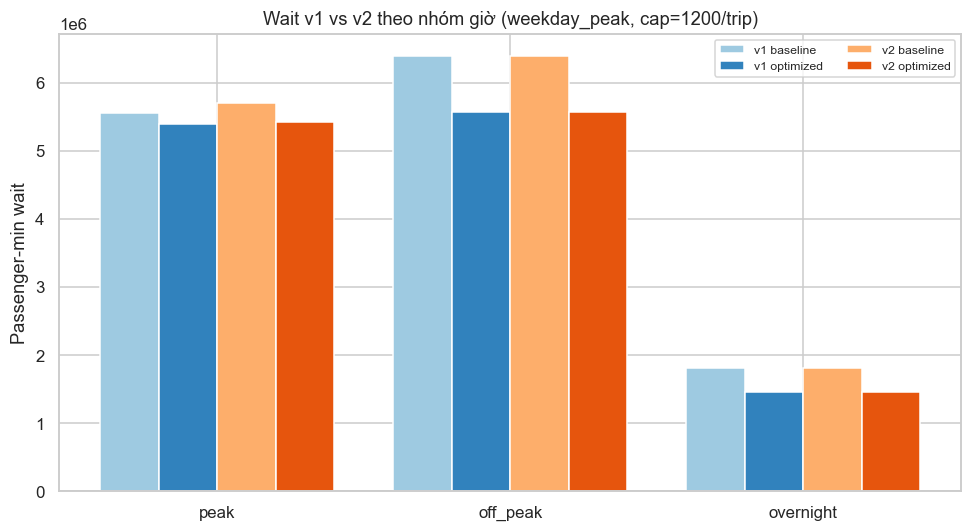

Đã lưu: outputs\default\wait_metric_comparison.csv | outputs\default\fig_wait_metric_comparison.png


In [24]:
dem_peak = scenario_demand["weekday_peak"]
trips_opt = opt_results["weekday_peak"]

def _legacy_slot_wait(demand_arr, trips_arr):
    trips_arr = np.maximum(np.asarray(trips_arr, dtype=float), 1.0)
    return np.asarray(demand_arr, dtype=float) * (60.0 / trips_arr / 2.0)

def _compare_wait_metrics(trips_arr, label):
    m_v1 = evaluate_schedule(trips_arr, dem_peak, lambda_cost=LAMBDA_COST)
    m_v2 = evaluate_schedule_v2(trips_arr, dem_peak, lambda_cost=LAMBDA_COST)
    return dict(
        label=label,
        wait_v1=m_v1["total_passenger_min_wait"],
        wait_v2=m_v2["total_passenger_min_wait"],
        overflow_pct=m_v2["overflow_pct"],
        total_overflow_pax=m_v2["total_overflow_pax"],
        slot_wait_v1=_legacy_slot_wait(dem_peak, trips_arr),
        slot_wait_v2=m_v2["slot_wait"],
    )

cmp = {
    "baseline": _compare_wait_metrics(baseline_trips, "baseline"),
    "optimized": _compare_wait_metrics(trips_opt, "optimized"),
}

base = cmp["baseline"]
opt = cmp["optimized"]
impr_v1 = (base["wait_v1"] - opt["wait_v1"]) / max(base["wait_v1"], 1e-9) * 100
impr_v2 = (base["wait_v2"] - opt["wait_v2"]) / max(base["wait_v2"], 1e-9) * 100
overestimate_pp = impr_v1 - impr_v2
overestimate_rel = overestimate_pp / max(impr_v2, 1e-9) * 100

print("=== Wait metric: headway/2 (v1) vs overflow (v2) — weekday_peak ===")
for k, c in cmp.items():
    print(f"  [{c['label']:10s}] v1={c['wait_v1']:>14,.0f} pax-min | v2={c['wait_v2']:>14,.0f} pax-min | "
          f"overflow slots={c['overflow_pct']:.1f}% | overflow pax={c['total_overflow_pax']:,.0f}")
print(f"\nImprovement v1 (metric cũ):  {impr_v1:+.2f}%")
print(f"Improvement v2 (metric mới): {impr_v2:+.2f}%")
print(f"Overestimate (v1 − v2):      {overestimate_pp:+.2f} pp "
      f"({overestimate_rel:+.1f}% so với improvement thực v2)")

# Bar chart theo nhóm giờ
def _group_wait(slot_wait):
    return srp.wait_totals_by_hour_groups(slot_wait, slot_hour).set_index("hour_group")["total_wait"]

grp_order = ["peak", "off_peak", "overnight"]
v1_base = _group_wait(base["slot_wait_v1"]).reindex(grp_order, fill_value=0)
v1_opt = _group_wait(opt["slot_wait_v1"]).reindex(grp_order, fill_value=0)
v2_base = _group_wait(base["slot_wait_v2"]).reindex(grp_order, fill_value=0)
v2_opt = _group_wait(opt["slot_wait_v2"]).reindex(grp_order, fill_value=0)

x = np.arange(len(grp_order))
w = 0.2
fig, ax = plt.subplots(figsize=(9, 5))
ax.bar(x - 1.5 * w, v1_base, width=w, label="v1 baseline", color="#9ecae1")
ax.bar(x - 0.5 * w, v1_opt, width=w, label="v1 optimized", color="#3182bd")
ax.bar(x + 0.5 * w, v2_base, width=w, label="v2 baseline", color="#fdae6b")
ax.bar(x + 1.5 * w, v2_opt, width=w, label="v2 optimized", color="#e6550d")
ax.set_xticks(x)
ax.set_xticklabels(grp_order)
ax.set_ylabel("Passenger-min wait")
ax.set_title(f"Wait v1 vs v2 theo nhóm giờ (weekday_peak, cap={CAPACITY_PER_TRIP}/trip)")
ax.legend(fontsize=8, ncol=2)
plt.tight_layout()
plt.savefig(OUT_DIR / "fig_wait_metric_comparison.png", dpi=120, bbox_inches="tight")
plt.show()

wait_metric_cmp = pd.DataFrame([
    dict(schedule=k, wait_v1=c["wait_v1"], wait_v2=c["wait_v2"],
         overflow_pct=c["overflow_pct"], total_overflow_pax=c["total_overflow_pax"])
    for k, c in cmp.items()
])
wait_metric_cmp["improve_v1_pct"] = np.nan
wait_metric_cmp["improve_v2_pct"] = np.nan
wait_metric_cmp.loc[wait_metric_cmp["schedule"] == "optimized", "improve_v1_pct"] = impr_v1
wait_metric_cmp.loc[wait_metric_cmp["schedule"] == "optimized", "improve_v2_pct"] = impr_v2
wait_metric_cmp.to_csv(OUT_DIR / "wait_metric_comparison.csv", index=False)
print("Đã lưu:", OUT_DIR / "wait_metric_comparison.csv", "|", OUT_DIR / "fig_wait_metric_comparison.png")

## 8. Đánh giá tổng hợp

So sánh baseline GTFS vs lịch tối ưu theo từng kịch bản: wait, fleet cost, objective, % interior bound.

Output: `results_summary.csv`, `tradeoff_summary.csv`, `fig_improvement.png`.

In [25]:
rows = []
for scen in scenario_demand:
    dem = scenario_demand[scen]
    base_wait = baseline_metrics[scen]["total_passenger_min_wait"]
    method_sols = [("Baseline", baseline_trips), ("Analytical", opt_results[scen])]
    for method, sol in method_sols:
        m = evaluate_schedule(sol, dem)
        rows.append(dict(
            scenario=scen, method=method, n_slots=N_SLOTS,
            total_passenger_min_wait=m["total_passenger_min_wait"],
            total_fleet_cost=m["total_fleet_cost"],
            weighted_avg_wait_min=m["weighted_avg_wait_min"],
            headway_std=m["headway_std"],
            total_trips=m["total_trips"],
            objective=m["objective"],
            wait_saved_vs_baseline=base_wait - m["total_passenger_min_wait"],
            fleet_cost_delta_vs_baseline=m["total_fleet_cost"] - baseline_metrics[scen]["total_fleet_cost"],
        ))

results_df = pd.DataFrame(rows)
base_obj_per_scen = results_df[results_df["method"] == "Baseline"].set_index("scenario")["objective"]
base_wait_per_scen = results_df[results_df["method"] == "Baseline"].set_index("scenario")["total_passenger_min_wait"]
results_df["objective_improvement_pct"] = results_df.apply(
    lambda r: (base_obj_per_scen[r["scenario"]] - r["objective"]) / base_obj_per_scen[r["scenario"]] * 100, axis=1)
results_df["wait_improvement_pct"] = results_df.apply(
    lambda r: (base_wait_per_scen[r["scenario"]] - r["total_passenger_min_wait"]) / base_wait_per_scen[r["scenario"]] * 100, axis=1)

_lam_note = ", ".join(f"{s}={lambda_used.get(s, LAMBDA_COST):.0f}" for s in scenario_demand)
print(f"=== Kết quả (Analytical, λ_eval={LAMBDA_COST}, λ_opt: {_lam_note}, {N_SLOTS} slots) ===")
print(results_df.round(3).to_string(index=False))
results_df.to_csv(OUT_DIR / "results_summary.csv", index=False)

tradeoff_df = results_df[results_df["method"] == "Analytical"]
tradeoff_show = tradeoff_df[["scenario", "wait_saved_vs_baseline", "fleet_cost_delta_vs_baseline",
    "objective_improvement_pct", "total_trips"]].rename(columns={
    "wait_saved_vs_baseline": "passenger_min_wait_saved",
    "fleet_cost_delta_vs_baseline": "fleet_cost_increase",
})
print("\n=== Trade-off Analytical vs Baseline ===")
print(tradeoff_show.round(0).to_string(index=False))
tradeoff_show.to_csv(OUT_DIR / "tradeoff_summary.csv", index=False)

_bound_rows = [{"scenario": scen, **row} for scen, rows in bound_by_hour.items() for row in rows]
if _bound_rows:
    pd.DataFrame(_bound_rows).to_csv(OUT_DIR / "bound_by_hour.csv", index=False)
    print("Đã lưu:", OUT_DIR / "bound_by_hour.csv")


=== Kết quả (Analytical, λ_eval=150.0, λ_opt: weekday_peak=384, weekend=384, rainy_day=384, 1104 slots) ===
    scenario     method  n_slots  total_passenger_min_wait  total_fleet_cost  weighted_avg_wait_min  headway_std  total_trips    objective  wait_saved_vs_baseline  fleet_cost_delta_vs_baseline  objective_improvement_pct  wait_improvement_pct
weekday_peak   Baseline     1104              13762699.557         1218600.0                  3.505        6.224       8124.0 14981299.557                   0.000                           0.0                      0.000                 0.000
weekday_peak Analytical     1104              12412428.494         1333950.0                  3.161        5.857       8893.0 13746378.494             1350271.063                      115350.0                      8.243                 9.811
     weekend   Baseline     1104               9730976.268         1218600.0                  3.718        6.224       8124.0 10949576.268                   0.000    

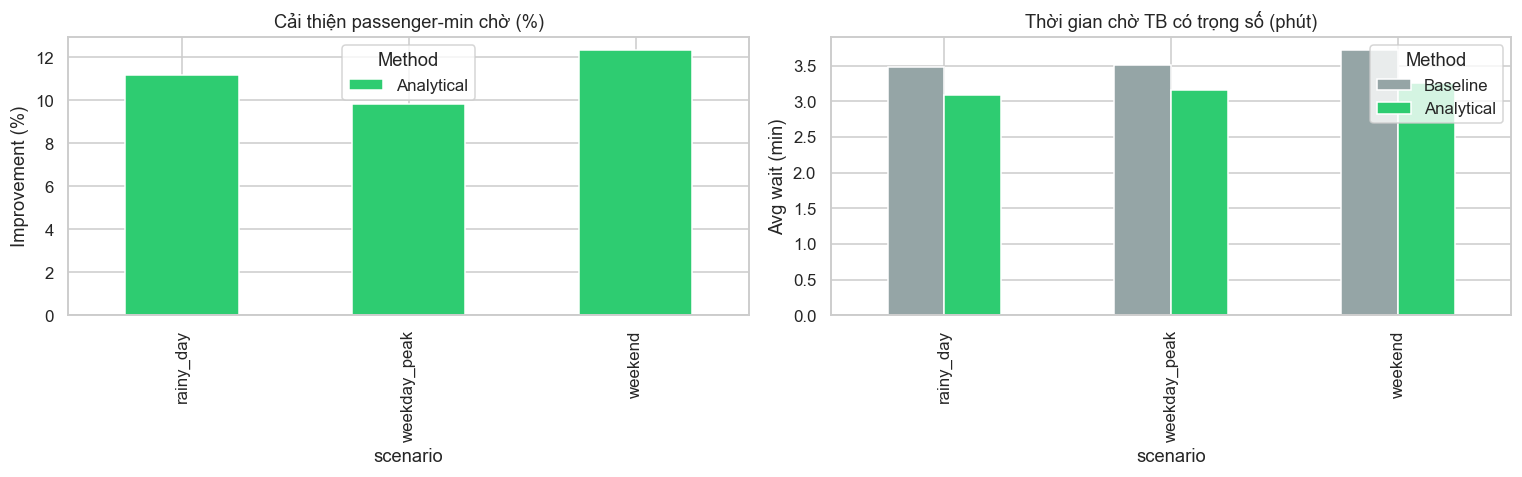

In [26]:
fig, axes = plt.subplots(1, 2, figsize=(14, 4.5))

best_label = "Analytical"
methods_impr = [best_label]
pivot = results_df.pivot(index="scenario", columns="method", values="wait_improvement_pct")
pivot = pivot[[c for c in methods_impr if c in pivot.columns]]
pivot.plot(kind="bar", ax=axes[0], color=["#2ECC71"])
axes[0].set_title("Cải thiện passenger-min chờ (%)")
axes[0].set_ylabel("Improvement (%)"); axes[0].legend(title="Method")

cols_wait = ["Baseline", best_label]
pivot2 = results_df.pivot(index="scenario", columns="method", values="weighted_avg_wait_min")[cols_wait]
pivot2.plot(kind="bar", ax=axes[1], color=["#95A5A6", "#2ECC71"])
axes[1].set_title("Thời gian chờ TB có trọng số (phút)")
axes[1].set_ylabel("Avg wait (min)"); axes[1].legend(title="Method")

plt.tight_layout()
plt.savefig(OUT_DIR / "fig_improvement.png", dpi=120, bbox_inches="tight")
plt.show()


## 9. Pareto frontier (báo cáo)

Frontier đầy đủ wait–cost cho báo cáo (khác §5b: có thể dùng nhiều điểm λ).

Output: `pareto_frontier.csv`, `fig_pareto_frontier.png`, `pareto_knee.json`.

=== Pareto frontier (weekday_peak) ===
Deploy λ=384 | knee λ=384 f1=10,044,514 f2=1,568,850


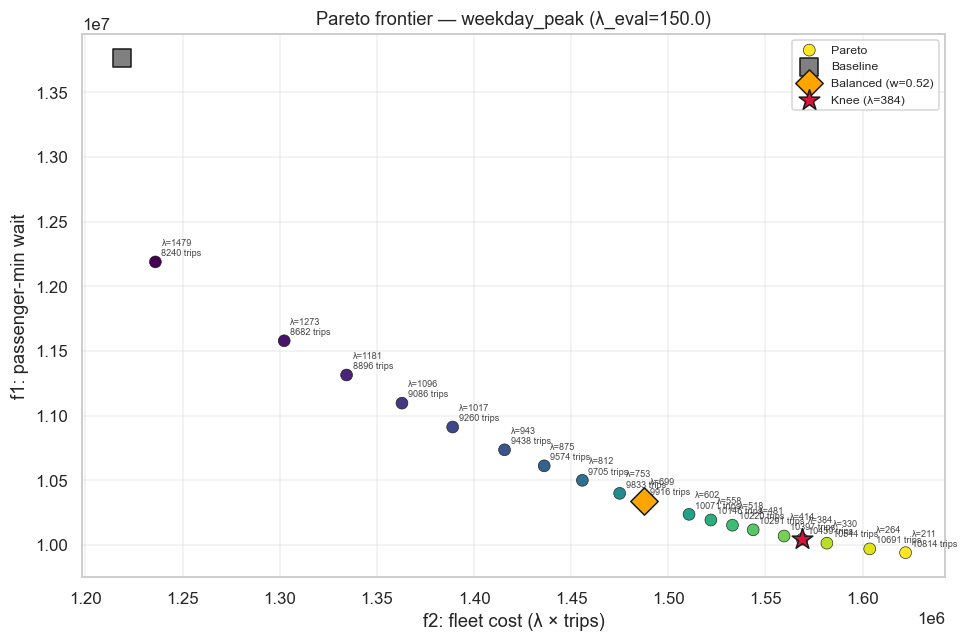

Đã lưu: outputs\default\pareto_frontier.csv | outputs\default\fig_pareto_frontier.png


In [27]:
def _pareto_optimize(demand, lambda_cost):
    return optimize_schedule_analytical(demand, lambda_cost=lambda_cost)

def _pareto_evaluate(trips, demand, lambda_cost):
    return evaluate_schedule(trips, demand, lambda_cost=lambda_cost)

if "pareto_df" not in globals():
    pareto_df = srp.generate_pareto_frontier(
        scenario_demand,
        baseline_trips,
        optimize_fn=_pareto_optimize,
        evaluate_fn=_pareto_evaluate,
        scenario="weekday_peak",
        n_points=PARETO_N_POINTS,
        lambda_eval=float(LAMBDA_COST),
        lambda_scan=np.unique(np.round(np.geomspace(30, 2500, 60)).astype(float)),
    )
    knee_row = srp.find_knee_point(pareto_df)
if "knee_row" not in globals():
    knee_row = srp.find_knee_point(pareto_df)
print("=== Pareto frontier (weekday_peak) ===")
print(
    f"Deploy λ={LAMBDA_OPT:.0f} | knee λ={knee_row['lambda_equiv']:.0f} "
    f"f1={knee_row['f1']:,.0f} f2={knee_row['f2']:,.0f}"
)
pareto_df.to_csv(OUT_DIR / "pareto_frontier.csv", index=False)

_base_peak = evaluate_schedule(baseline_trips, scenario_demand["weekday_peak"], lambda_cost=LAMBDA_COST)
fig, ax = plt.subplots(figsize=(9, 6))
srp.plot_pareto_frontier(
    pareto_df,
    baseline_f1=_base_peak["total_passenger_min_wait"],
    baseline_f2=_base_peak["total_fleet_cost"],
    ax=ax,
    title=f"Pareto frontier — weekday_peak (λ_eval={LAMBDA_COST})",
    save_path=OUT_DIR / "fig_pareto_frontier.png",
)
plt.show()
print("Đã lưu:", OUT_DIR / "pareto_frontier.csv", "|", OUT_DIR / "fig_pareto_frontier.png")


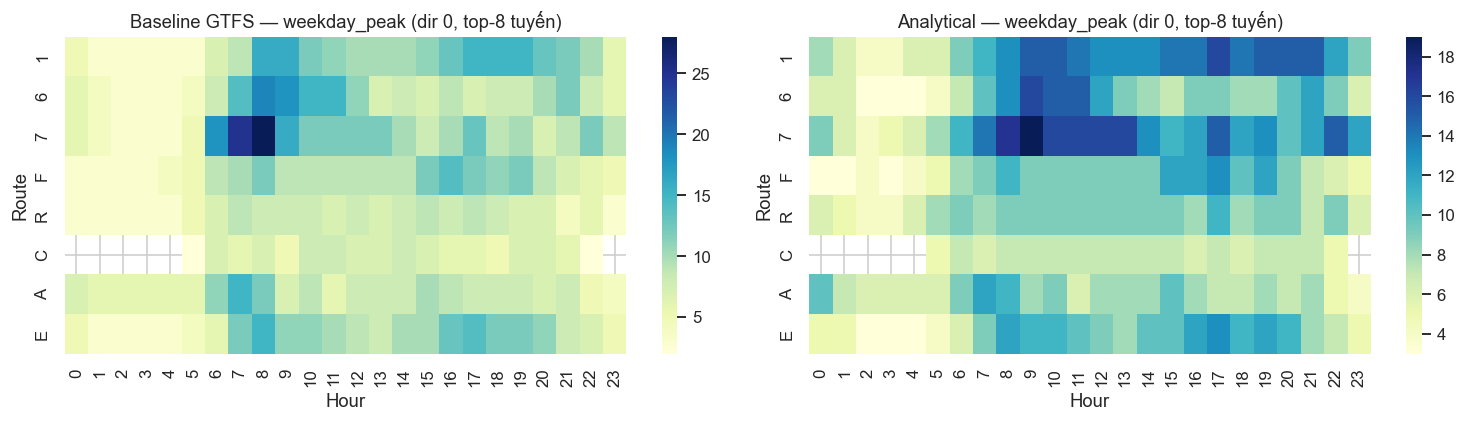

In [28]:
def reshape_trip_matrix(sol: np.ndarray, direction: int, routes: list) -> pd.DataFrame:
    sub = pd.DataFrame({
        "route": slot_route, "dir": slot_dir, "hour": slot_hour, "trips": sol
    })
    sub = sub[sub["dir"] == direction]
    return sub.pivot(index="route", columns="hour", values="trips").reindex(routes)

HEATMAP_ROUTES = [r for r in route_totals.index.astype(str) if r in set(OPT_ROUTES)][:8]
if not HEATMAP_ROUTES:
    HEATMAP_ROUTES = list(OPT_ROUTES)[:8]
scen_to_show = "weekday_peak"
best_label = "Analytical"
fig, axes = plt.subplots(1, 2, figsize=(14, 4))
for ax, (method, sol) in zip(axes, [
    ("Baseline GTFS", baseline_trips),
    (best_label, opt_results[scen_to_show]),
]):
    m = reshape_trip_matrix(sol, direction=0, routes=HEATMAP_ROUTES)
    sns.heatmap(m, annot=False, fmt=".0f", cmap="YlGnBu", ax=ax)
    ax.set_title(f"{method} — {scen_to_show} (dir 0, top-8 tuyến)")
    ax.set_xlabel("Hour"); ax.set_ylabel("Route")
plt.tight_layout()
plt.savefig(OUT_DIR / f"fig_schedule_{scen_to_show}.png", dpi=120, bbox_inches="tight")
plt.show()


In [29]:
summary_metrics = {
    "run_experiment": "default",
    "demand_model_type": "blend",
    "n_slots": int(N_SLOTS),
    "n_routes": int(len(OPT_ROUTES)),
    "n_hours": int(len(OPT_HOURS)),
    "routes": list(OPT_ROUTES),
    "opt_method": "Analytical",
    "n_headway_fallback": int(n_fallback),
    "scenarios": list(scenario_demand.keys()),
    "lambda_cost_default": float(LAMBDA_COST),
    "lambda_opt": float(LAMBDA_OPT),
    "lambda_used": {k: float(v) for k, v in lambda_used.items()},
    "split_demand_by_direction": bool(SPLIT_DEMAND_BY_DIRECTION),
    "bound_status": {s: srp.bound_status_jsonable(st) for s, st in bound_status.items()},
    "bound_by_hour": bound_by_hour if "bound_by_hour" in dir() else {},
    "opt_target": str(globals().get("OPT_TARGET", "objective")),
    "lambda_candidates": [float(x) for x in globals().get("LAMBDA_CANDIDATES", LAMBDA_GRID)],
    "baseline": {s: baseline_metrics[s] for s in scenario_demand},
    "optimized": {s: evaluate_schedule(opt_results[s], scenario_demand[s])
                  for s in scenario_demand},
    "nn_eval": nn_eval_metrics,
    "pareto_frontier_weekday_peak": pareto_df.to_dict(orient="records"),
    "pareto_knee_weekday_peak": srp.json_default(knee_row),
}

srp.dump_json(OUT_DIR / "baseline_metrics.json", summary_metrics, indent=2)
print("Đã ghi:", OUT_DIR / "baseline_metrics.json")


Đã ghi: outputs\default\baseline_metrics.json


## 10. Export cho UI/API

Gói model + optimizer state + schedules vào `outputs/default/ui_export/` — API **không** re-train.

| Nhóm | File chính |
|------|------------|
| Demand | `demand_model.keras`, `scaler.pkl`, `histgbm_blend.pkl`, `demand_inference.pkl`, `quantile_gbm.pkl` |
| Baseline | `baseline_lookup.json`, `fallback_baseline.json`, `lag_feature_defaults.json` |
| Optimizer | `ui_config.json`, `optimizer_state.pkl`, `schedule_{scenario}.json` |
| Metrics | `baseline_metrics.json`, `pareto_frontier.json`, `manifest.json` |

Công thức: `Demand = exp(log_baseline + pred_residual) - 1`. Inference: `notebooks/lib/demand_runtime.py`.

In [30]:
import json
import joblib
import shutil
from datetime import datetime, timezone

UI_DIR = OUT_DIR / "ui_export"
UI_DIR.mkdir(parents=True, exist_ok=True)

# Đảm bảo blend weight đã tune trước khi export
tune_blend_weight_mlp()

# --- C1. Demand model artifacts ---
model.save(UI_DIR / "demand_model.keras")
joblib.dump(scaler, UI_DIR / "scaler.pkl")
if histgbm_model is not None:
    joblib.dump(histgbm_model, UI_DIR / "histgbm_blend.pkl")
if "quantile_models" in globals():
    joblib.dump(quantile_models, UI_DIR / "quantile_gbm.pkl")

# --- C1b. Baseline lookup + inference bundle (API demand prediction) ---
baseline_lookup.reset_index().to_json(
    UI_DIR / "baseline_lookup.json", orient="records", indent=2, force_ascii=False
)
fallback.reset_index().to_json(
    UI_DIR / "fallback_baseline.json", orient="records", indent=2, force_ascii=False
)
srp.dump_json(UI_DIR / "lag_feature_defaults.json", lag_feature_defaults, indent=2)

_feature_med_cols = [c for c in NUM_FEATURES if c in df.columns and c != "log_baseline"]
feature_medians = {
    c: float(pd.to_numeric(df[c], errors="coerce").median()) for c in _feature_med_cols
}
srp.dump_json(UI_DIR / "feature_medians.json", feature_medians, indent=2)

_fb_route = df.groupby(["route_id", "is_weekend"])["demand"].median().rename("fb_route_weekend")
_fb_hour = df.groupby(["hour", "is_weekend"])["demand"].median().rename("fb_hour_weekend")
_fb_global = float(pd.to_numeric(df["demand"], errors="coerce").dropna().median())
if not np.isfinite(_fb_global) or _fb_global <= 0:
    _fb_global = 100.0

demand_inference = {
    "scaler": scaler,
    "histgbm_model": histgbm_model,
    "blend_mlp_weight": float(blend_weight_mlp),
    "resid_clip": tuple(RESID_CLIP),
    "num_features": list(NUM_FEATURES),
    "route_to_idx": {str(k): int(v) for k, v in route_to_idx.items()},
    "baseline_lookup": baseline_lookup,
    "fallback": fallback,
    "lag_feature_defaults": lag_feature_defaults,
    "feature_medians": feature_medians,
    "fb_route_weekend": _fb_route,
    "fb_hour_weekend": _fb_hour,
    "fb_global": _fb_global,
    "use_route_embedding": bool(USE_ROUTE_EMBEDDING),
    "use_lag_features": bool(USE_LAG_FEATURES),
    "lag_feature_cols": list(LAG_FEATURE_COLS),
    "hourly_factor_cols": list(HOURLY_FACTOR_COLS),
}
joblib.dump(demand_inference, UI_DIR / "demand_inference.pkl")

# --- C2. Route & slot metadata ---
route_meta = {
    "opt_routes": [str(r) for r in OPT_ROUTES],
    "ridership_routes": [str(r) for r in RIDERSHIP_ROUTES],
    "missing_ridership_routes": [str(r) for r in MISSING_RIDERSHIP_ROUTES],
    "route_to_idx": {str(k): int(v) for k, v in route_to_idx.items()},
    "route_dir_hours": {
        f"{r}|{d}": [int(h) for h in hs]
        for (r, d), hs in route_dir_hours.items()
    },
    "n_slots": int(N_SLOTS),
    "directions": [int(d) for d in DIRECTIONS],
    "opt_hours": [int(h) for h in OPT_HOURS],
}
srp.dump_json(UI_DIR / "route_meta.json", route_meta, indent=2)

# --- C3. Tunable config snapshot (UI form defaults) ---
ui_config = {
    "demand_model_type": "blend",
    "spillover_alpha_global": float(SPILLOVER_ALPHA),
    "spillover_alpha_per_route": {str(k): float(v) for k, v in SPILLOVER_ALPHA_ROUTE.items()},
    "resid_clip": float(RESID_CLIP[1]),
    "blend_mlp_weight": float(blend_weight_mlp),
    "lambda_opt": float(LAMBDA_OPT),
    "lambda_cost_eval": float(LAMBDA_COST),
    "lambda_candidates": [float(x) for x in LAMBDA_CANDIDATES],
    "opt_target": str(OPT_TARGET),
    "trips_peak_max_factor": float(TRIPS_PEAK_MAX_FACTOR),
    "trips_offpeak_max_factor": float(TRIPS_OFFPEAK_MAX_FACTOR),
    "trips_overnight_max_factor": float(TRIPS_OVERNIGHT_MAX_FACTOR),
    "trips_min_factor": float(TRIPS_MIN_FACTOR),
    "trips_overnight_min_factor": float(TRIPS_OVERNIGHT_MIN_FACTOR),
    "use_pareto_knee_lambda": bool(USE_PARETO_KNEE_LAMBDA),
    "risk_scenarios": list(RISK_SCENARIOS),
    "risk_demand_quantile": float(RISK_DEMAND_QUANTILE),
    "trips_max_delta": int(TRIPS_MAX_DELTA),
    "min_headway_min": float(MIN_HEADWAY_MIN),
    "max_headway_min": float(MAX_HEADWAY_MIN),
    "turnaround_buffer_min": float(TURNAROUND_BUFFER_MIN),
    "max_system_fleet": float(max_system_fleet),
    "max_overflow_pct": float(MAX_OVERFLOW_PCT),
    "smoothness_max_delta": int(SMOOTHNESS_MAX_DELTA),
    "target_max_bind_fraction": float(TARGET_MAX_BIND_FRACTION),
    "target_peak_bind_fraction": float(TARGET_PEAK_BIND_FRACTION),
    "rainy_peak_trips_min_factor": float(RAINY_PEAK_TRIPS_MIN_FACTOR),
    "overnight_max_headway_min": float(OVERNIGHT_MAX_HEADWAY_MIN),
    "rainy_offpeak_max_factor": float(RAINY_OFFPEAK_MAX_FACTOR),
    "use_demand_spillover": bool(USE_DEMAND_SPILLOVER),
    "transfer_min_weight": float(TRANSFER_MIN_WEIGHT),
    "scenarios": list(SCENARIOS),
    "rainy_hour_boost": {str(k): float(v) for k, v in RAINY_HOUR_BOOST.items()},
    "num_features": list(NUM_FEATURES),
    "lag_feature_cols": list(LAG_FEATURE_COLS),
    "nn_hidden": list(NN_HIDDEN),
    "capacity_per_trip": int(CAPACITY_PER_TRIP),
    "use_route_embedding": bool(USE_ROUTE_EMBEDDING),
    "split_demand_by_direction": bool(SPLIT_DEMAND_BY_DIRECTION),
    "lambda_auto_calibrate": bool(LAMBDA_AUTO_CALIBRATE),
}
srp.dump_json(UI_DIR / "ui_config.json", ui_config, indent=2)

# --- C4. Optimizer replay state ---
joblib.dump(
    {
        "baseline_trips": baseline_trips,
        "TRIPS_MIN": TRIPS_MIN,
        "TRIPS_MAX": TRIPS_MAX,
        "slot_route": slot_route,
        "slot_dir": slot_dir,
        "slot_hour": slot_hour,
        "direction_share": direction_share,
        "baseline_lookup": baseline_lookup,
        "fallback": fallback,
        "lag_feature_defaults": lag_feature_defaults,
        "fb_route_weekend": _fb_route,
        "fb_hour_weekend": _fb_hour,
        "fb_global": _fb_global,
        "service_windows": service_windows,
        "cycle_times": cycle_times,
        "fleet_by_route_dir": fleet_by_route_dir,
        "max_system_fleet": float(max_system_fleet),
        "transfer_matrix": transfer_matrix,
        "scenario_demand": {s: scenario_demand[s] for s in SCENARIOS},
    },
    UI_DIR / "optimizer_state.pkl",
)

# --- C5. Pareto frontier ---
pareto_df.to_json(UI_DIR / "pareto_frontier.json", orient="records", indent=2, force_ascii=False)
srp.dump_json(UI_DIR / "pareto_knee.json", srp.json_default(knee_row), indent=2)

# --- C6. Optimized schedules per scenario ---
for scen in SCENARIOS:
    tmin, tmax = trips_bounds_for_scenario(scen)
    sched = pd.DataFrame({
        "route": slot_route,
        "direction": slot_dir,
        "hour": slot_hour,
        "baseline_trips": baseline_trips,
        "opt_trips": opt_results[scen],
        "demand_pred": scenario_demand[scen],
        "trips_min": tmin,
        "trips_max": tmax,
        "at_max": (opt_results[scen] >= tmax).astype(int),
    })
    sched.to_json(UI_DIR / f"schedule_{scen}.json", orient="records", indent=2, force_ascii=False)

# --- C7. Spillover benefit by route ---
if "spillover_benefit" in globals():
    spillover_benefit.to_json(UI_DIR / "spillover_benefit.json", orient="records", indent=2, force_ascii=False)


if "uncertainty_route_hour" in globals():
    uncertainty_route_hour.to_json(
        UI_DIR / "uncertainty_route_hour.json", orient="records", indent=2, force_ascii=False
    )

# --- C9. Run metrics snapshot + copy full baseline_metrics ---
run_metrics = {
    "exported_at": datetime.now(timezone.utc).isoformat(),
    "out_dir": str(OUT_DIR),
    "lambda_used": {k: float(v) for k, v in lambda_used.items()},
    "bound_status": {s: srp.bound_status_jsonable(st) for s, st in bound_status.items()},
    "bound_by_hour": bound_by_hour,
    "optimized": summary_metrics["optimized"],
    "baseline": summary_metrics["baseline"],
    "pareto_knee": srp.json_default(knee_row),
}
srp.dump_json(UI_DIR / "run_metrics.json", run_metrics, indent=2)

_src_bm = OUT_DIR / "baseline_metrics.json"
if _src_bm.exists():
    shutil.copy(_src_bm, UI_DIR / "baseline_metrics.json")

manifest = {
    "exported_at": run_metrics["exported_at"],
    "ui_dir": str(UI_DIR),
    "files": sorted(p.name for p in UI_DIR.iterdir() if p.is_file()),
}
srp.dump_json(UI_DIR / "manifest.json", manifest, indent=2)

print(f"✓ UI export → {UI_DIR.resolve()}")
print(f"  {len(manifest['files'])} files:", ", ".join(manifest["files"]))


✓ UI export → D:\tranport-public\notebooks\outputs\default\ui_export
  21 files: baseline_lookup.json, baseline_metrics.json, demand_inference.pkl, demand_model.keras, fallback_baseline.json, feature_medians.json, histgbm_blend.pkl, lag_feature_defaults.json, optimizer_state.pkl, pareto_frontier.json, pareto_knee.json, quantile_gbm.pkl, route_meta.json, run_metrics.json, scaler.pkl, schedule_rainy_day.json, schedule_weekday_peak.json, schedule_weekend.json, spillover_benefit.json, ui_config.json, uncertainty_route_hour.json


## 11. Kết luận

**Demand (hold-out autumn_2025):** blend MLP + HistGBM — MAE ≈489, R² ≈0.98; spillover α=0.02; feature thời tiết liên tục từ `factors_hourly.csv`.

**Tối ưu (λ knee ≈384):** cải thiện objective ~8–10% so baseline GTFS; interior bound 67–68% (đêm ~64%); wait v2 giảm ~10–12% theo kịch bản; overflow optimized <0.5%.

**Triển khai:** chạy §10 → `outputs/default/ui_export/`.